# Kaggriculture: Scenario-Aware Economic Policy

Terminal utility is determined by comparing the two terminal banks.
Every field asset is therefore part of a cash-conversion chain rather
than an end in itself:

$$
\text{cash}
\rightarrow
\text{land, labor, seed, livestock}
\rightarrow
\text{field output}
\rightarrow
\text{shed inventory}
\rightarrow
\text{market sale}
\rightarrow
B_T.
$$

A production choice is useful only when the complete chain remains
plausible before the horizon. Gross yield alone is insufficient: the
same asset can lose value through missed care, worker travel, shed
congestion, market impact, or late unsold inventory. The control
problem is consequently separated into five coupled decisions:

1. choose a phase from remaining time and operational risk;
2. reserve land for production lines with positive bounded value;
3. generate time- and inventory-screened candidate jobs;
4. match workers to jobs by loss prevention, value, and travel;
5. allocate cash and market capacity while reserving liquidity and
   capacity for future feed, storage, and liquidation.

The dominant failure modes are treated asymmetrically. A second missed
feed or water can destroy an existing investment, so it receives a
hard priority. Ordinary planting, care, harvesting, and construction
compete through economic value. Near the terminal horizon, production
value collapses unless harvest, return, storage, and sale all fit in
the remaining actions.

| Layer | Rule |
|---|---|
| State | Phase, liquidity, workload, storage, visible competing supply |
| Production | Staged cow–sheep herd + strawberry expansion + bounded melon + feed wheat |
| Geometry | Stable quadrant roles; recurring work nearest accessible shed tiles |
| Scheduling | Loss prevention → global value-distance matching |
| Capital | Staged livestock and land + workload-scaled labor + operating reserves |
| Trading | Marginal price curve + town drain + visible supply + storage pressure |
| Terminal | Feasible harvest → return → capacity-safe unload → sale |

In [1]:
from pathlib import Path
from importlib import metadata
from IPython.core.magic import register_cell_magic
import contextlib
import io
import subprocess
import sys

IS_KAGGLE = Path("/kaggle/working").is_dir()
if IS_KAGGLE:
    WORK_DIR = Path("/kaggle/working")
else:
    project_root = Path.cwd()
    if project_root.name == "notebooks":
        project_root = project_root.parent
    WORK_DIR = project_root / "artifacts" / "notebook_baseline"

WORK_DIR.mkdir(parents=True, exist_ok=True)
MAIN_PATH = WORK_DIR / "main.py"

@register_cell_magic
def agentfile(line, cell):
    # Append source chunks to main.py.
    mode = "a" if line.strip() == "append" else "w"
    with MAIN_PATH.open(mode, encoding="utf-8") as handle:
        handle.write(cell)

REQUIRED_ENV_VERSION = "1.32.2"

try:
    env_version = metadata.version("kaggle-environments")
except metadata.PackageNotFoundError:
    env_version = "0.0.0"

if IS_KAGGLE and env_version != REQUIRED_ENV_VERSION:
    install = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--disable-pip-version-check",
            "--no-input",
            "--upgrade",
            "kaggle-environments==1.32.2",
        ],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if install.returncode != 0:
        raise RuntimeError(
            "kaggle-environments installation failed:\n"
            + install.stdout[-4000:]
        )
    env_version = metadata.version("kaggle-environments")

assert env_version == REQUIRED_ENV_VERSION, (
    "kaggle-environments==1.32.2 required; "
    f"found {env_version}."
)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(
    io.StringIO()
):
    from kaggle_environments import make

probe = make("kaggriculture")
print({
    "kaggle_environments": env_version,
    "episode_steps": int(probe.configuration.episodeSteps),
    "act_timeout_seconds": float(probe.configuration.actTimeout),
    "market_orders_per_turn": int(
        probe.configuration.maxMarketOrdersPerTurn
    ),
})

{'kaggle_environments': '1.32.2', 'episode_steps': 720, 'act_timeout_seconds': 1.0, 'market_orders_per_turn': 10}


## 1. State, action, and objective

The environment contains 30 days of 24 states, but actions are issued
only for steps $0$ through $718$. The last actionable state therefore
defines the operational horizon, not the nominal count of 720 states.
Remaining-action calculations use this distinction explicitly.

$$
N_{\text{players}}=2,\qquad
D=30,\qquad
H_{\text{day}}=24,\qquad
T_{\text{states}}=720.
$$

$$
t\in\{0,\ldots,718\},
\qquad
N_{\text{decisions}}=719.
$$

$$
a_t =
\left(
  a_t^{\text{farmer}},
  a_t^{\text{hand }1},\ldots,a_t^{\text{hand }H_t},
  \mathcal{M}_t
\right),
$$

$$
N_{\text{field actions}}(u,t)=1
\quad\forall u,\qquad
\lvert\mathcal{M}_t\rvert\le10.
$$

$$
U(\pi,\pi^{-})
=\mathbf{1}\!\left[B_T^\pi>B_T^{\pi^{-}}\right]
+\frac12\mathbf{1}\!\left[B_T^\pi=B_T^{\pi^{-}}\right],
\qquad
\pi^*=\arg\max_\pi\mathbb E[U(\pi,\pi^{-})].
$$

Terminal bank creates a sharp boundary condition. Seed, crops,
products carried by workers, and products left in the shed have no
independent terminal value. Their value is the cash that can still be
realized after all required field and market actions. For a field
target $z$, a Manhattan lower-bound screen checks travel to $z$, the
field action, return to an accessible shed tile, and unloading. Legal
BFS routing is still checked during assignment, and the screen does not
guarantee that competing work, capacity, and market slots remain.
Bank and margin summarize within-game conversion efficiency; they are
diagnostics, while win/tie/loss utility remains the optimization target.

| Order or condition | Effect |
|---|---|
| Field stage before market stage | Same-turn drops become saleable |
| Field stage before `BUY_SEED` | Bought seed cannot fund the current `PLANT` |
| Plant requests exceed seed stock | Every request for that crop becomes `PASS` |
| Multi-unit buy or sell | Unitwise execution; partial fill possible |
| `HIRE` or `BUY_LAND` | One-shot execution |
| Shared market stock | Both agents affect later marginal prices |

$$
D_{c,t}:=
\#\{u\in\mathcal U_t:
  a_{u,t}=\operatorname{PLANT}(c)\},
\qquad
D_{c,t}>S_{c,t}
\quad\Longrightarrow\quad
\operatorname{Exec}(a_{u,t})=\operatorname{PASS}
\quad
\forall u\in\mathcal U_t:
  a_{u,t}=\operatorname{PLANT}(c).
$$

Processing order creates two important asymmetries. A product dropped
during the field stage is available to a sale in the same turn, while
seed purchased in the market stage cannot support a plant action that
has already been processed. Plant missions must therefore be covered
by seed already present at the start of the turn. Since an aggregate
seed shortfall cancels every same-crop plant request, seed reservation
is committed only after a route-valid worker--mission pair is selected.

The market is a simultaneous shared system. Selling one more unit
changes the marginal price of later units and may interact with the
opponent order in the same round. Market decisions consequently use
unitwise price sums, visible opponent supply, and a conservative cash
discount instead of multiplying quantity by the displayed spot price.

## 2. Production economics

A field asset consumes a tile, purchase cash, worker actions, storage,
and liquidation capacity. The portfolio therefore separates recurring
output from concentrated one-time output. Strawberries provide the
long-horizon recurring crop line, cows and sheep provide two distinct
animal-product lines, melon supplies bounded high-value exposure, and
wheat protects the herd. Carrot occupies only a small residual hedge.

### 2.1 Crop value

$$
\mathcal C_{\text{one}}
=\{\text{WHEAT},\text{CARROT},\text{MELON}\},
\qquad
\mathcal C_{\text{ongoing}}
=\{\text{TOMATO},\text{STRAWBERRY}\}.
$$

$$
\mathcal{W}_c=
\left\{
  d:
  \left\lceil\frac{m_c}{2}\right\rceil
  \le d\le m_c
\right\}.
$$

$$
Y_c(h)=
\min\!\left(
  Y_c^{\max},
  1+
  \sum_{d\in\mathcal{W}_c,\;d\le h}
  \mathbf{1}[\text{watered}_d]
  \left(1+\mathbf{1}[\text{fertilized}_d]\right)
\right).
$$

One-time crops gain yield only from watering inside their crop-specific
bonus window; active fertilizer doubles that day's bonus increment.
Watering outside that window preserves the crop only after a prior
miss; otherwise it has no modeled marginal yield. An ongoing crop is
watered from one day before its first production and harvested near
its holding cap. These rules avoid daily work that does not protect an
asset or increase realizable output.

| Crop | Seed | First yield | Ripe | Max yield |
|---|---:|---:|---:|---:|
| Wheat | 10 | 2 | 4 | 6 |
| Carrot | 20 | 2 | 3 | 4 |
| Tomato | 50 | 8 | 8 | 4 |
| Strawberry | 100 | 10 | 10 | 4 |
| Melon | 80 | 10 | 10 | 6 |

| Crop | Mode | Max-yield day | Plant cutoff |
|---|---|---:|---:|
| Wheat | one-time | 4 | day 24 |
| Carrot | one-time | 3 | day 25 |
| Tomato | ongoing | 8 | day 19 |
| Strawberry | ongoing | 10 | day 18 |
| Melon | one-time | 12 | day 18 |

Melon supply is capped because its glut curve is quadratic. Current
price and visible rival melon tiles select one of four acreage levels:

$$
M_t=
\begin{cases}
  12,&p_M\ge300\land N_M^-\le5,\\
  8,&p_M\le170\lor N_M^-\ge12,\\
  9,&N_M^-\ge9,\\
  10,&\text{otherwise}.
\end{cases}
$$

$$
f_{\text{melon}}^+(x)=x^2,
\qquad
M_t\in\{8,9,10,12\}.
$$

The first unlocked quadrant reserves four animal cells. Its remaining
cells contain bounded melon, four wheat, two carrot, and strawberry in
every residual cell. The first two expansions reserve five and three
animal cells respectively; each assigns four wheat and one carrot, then
fills all residual cells with strawberry. At default geometry this
yields 12 feed-wheat cells, four carrot cells, 8--12 melon cells, and
35--39 strawberry cells across three quadrants.

$$
N_{q,\text{strawberry}}
=
\left[
  K_q-N_{q,\text{animal}}-N_{q,\text{fixed crop}}
\right]^+.
$$

Strawberry receives residual expansion capacity because a planted
ongoing crop can emit repeatedly without seed repurchase or replanting.
Its long delay makes early acreage valuable and late acreage fragile;
the day-18 plant guard remains an outer legality bound. Feed wheat is
deliberately smaller than daily herd demand because market purchase
converts cash into wheat without consuming planting, watering,
harvesting, and transport actions on every required unit.

### 2.2 Livestock portfolio

Cows and sheep occupy pastures and produce different premium goods.
The first four roles are fixed at two cows and two sheep. Later slots
are assigned one at a time from price, public demand, visible rival
herd size, and self-crowding:

$$
s_a(t)=
\frac{p_{r(a),t}}{b_{r(a)}}
\frac{1+0.012D_{r(a),t}^{\text{town}}}
     {1+0.18N_{a,t}^{-}+0.08N_{a,t}^{\text{target}}},
\qquad
a\in\{\text{COW},\text{SHEEP}\}.
$$

| Animal | Cost | Structure | First / interval | Holding cap |
|---|---:|---|---:|---:|
| Cow | 400 | Pasture | 8 / 2 days | 6 |
| Sheep | 500 | Pasture | 6 / 3 days | 6 |

Owned pipeline stock includes placed, shed, and carried animals:

$$
O_{a,t}=N_{a,t}^{\text{placed}}
+N_{a,t}^{\text{shed}}
+N_{a,t}^{\text{carried}}.
$$

$$
G(d)=
\begin{cases}
  4,&d<7,\\
  8,&7\le d<11,\\
  12,&d\ge11,
\end{cases}
\qquad
G_t^*=\min\!\left(C_t^{\text{pasture}},
  \max\!\left(\sum_aO_{a,t},G(d_t)\right)\right).
$$

New purchases stop after day 18 or with fewer than eight days left;
the target then freezes at owned pipeline stock. Counting transit stock
prevents duplicate orders. Purchase orders are capped at two per
species and constrained by cash and shed capacity; structures can be
completed while purchased animals wait in storage.

Each placed animal consumes one wheat on every fed day. `FEED` prevents
escape and dominates ordinary work after one prior miss. Under the
execution engine, a surviving fed and cared animal adds one pending
bonus unit at daily refresh. Let $\sigma_{a,d}$ indicate that production
is scheduled at the refresh after day $d$. Existing pending care is
consumed and reset at that production; care performed on the production
day is added only afterward and belongs to the following cycle.

$$
P_{a,d+1}^{\text{care}}
=(1-\sigma_{a,d})P_{a,d}^{\text{care}}
+\mathbf 1[\text{fed}_{a,d}\land\text{cared}_{a,d}],
$$

$$
Y_{a,d+1}^{\text{held}}
=\min\!\left(Y_a^{\max},
  Y_{a,d}^{\text{held}}
  +\sigma_{a,d}\left(
    1+\mathbf 1[\text{fed}_{a,d}]
    P_{a,d}^{\text{care}}
  \right)
\right).
$$

The base unit is produced on a scheduled surviving refresh even after
a first missed feed; an unfed production loses the old pending bonus.
Care is offered only through day 27, while its next-cycle unit can fit,
and when product price is at least 20. On a production day, existing
pending care is excluded from the care-admission bound because it is
consumed and reset; today's care is not part of imminent yield.
Harvest always requires positive held yield. It is offered at three
held units, when imminent production would fill or exceed the holding
cap, or from day 27 onward. Fertilizer is collected
as a saleable by-product; no fertilizer-application job is created.

### 2.3 Daily labor cost

Labor has convex daily cost. The marginal hand becomes rapidly more
expensive, and a newly hired hand cannot act until the following turn.
Hands disappear at the day boundary, return their carried inventory to
available shed space, and the Fibonacci hire counter resets.
Ten hands form the productive floor through day 27 whenever active
roles exist. Additional hands are justified only by the number of due
jobs and assets already at risk.

$$
F_0=F_1=1,\qquad
F_n=F_{n-1}+F_{n-2},\qquad
C_{\text{hands}}(H)=\sum_{n=0}^{H-1}F_n.
$$

| Hands | 6 | 8 | 10 | 12 |
|---:|---:|---:|---:|---:|
| Daily cost | 20 | 54 | 143 | 376 |

$$
R_t=N_t^{\text{animal risk}}+N_t^{\text{crop risk}},
\qquad
H_t^*=\operatorname{clip}_{[4,12]}
\left(
  \max\!\left(H_t^{\text{floor}},
    \left\lceil\frac{J_t^{\text{due}}+2R_t}{7}\right\rceil
  \right)
\right),
$$

$$
H_t^{\text{floor}}=
\begin{cases}
  10,&d_t\le27\land N_t^{\text{active role}}>0,\\
  4,&\text{otherwise}.
\end{cases}
$$

Hiring is restricted to hours 0--2. A marginal hire is admitted only
when planning cash is at least the larger of 20 and three times its
Fibonacci cost. Since a new hand begins acting on the next observation,
the early-hour gate preserves enough same-day actions to recover even a
cheap wage.

## 3. Shared-market model

Market inventory is the state variable behind price. Buying removes
units from the market and raises subsequent marginal prices; selling
adds units and lowers them. The response is nonlinear and
product-specific, so a quantity-$q$ order must be evaluated as a sum of
marginal units. Melon and wool are especially vulnerable to excess
supply because their above-equilibrium curves use a squared shape.

$b_r$ is the equilibrium price, $T_r$ is the calibration throughput,
$f_r^-$ and $f_r^+$ are scarcity and glut shapes, and
$\tau_r^-$ and $\tau_r^+$ are their relative target movements. Observed
configuration overrides replace these defaults when present.

| Product | Base | Scale | Scarcity: shape, move | Glut: shape, move |
|---|---:|---:|---|---|
| Wheat | 25 | 400 | `sqrt(x)`, 0.80 | `log1p(x)`, 0.20 |
| Carrot | 35 | 450 | `log1p(x)`, 0.20 | `sqrt(x)`, 0.70 |
| Tomato | 60 | 200 | `x`, 0.40 | `sqrt(x)`, 0.60 |
| Strawberry | 120 | 100 | `sqrt(x)`, 0.70 | `x`, 1.60 |
| Melon | 250 | 300 | `log1p(x)`, 0.20 | `x^2`, 3.60 |
| Egg | 50 | 332 | `x`, 0.40 | `log1p(x)`, 0.20 |
| Milk | 160 | 122 | `sqrt(x)`, 0.60 | `x`, 1.60 |
| Wool | 200 | 105 | `log1p(x)`, 0.20 | `x^2`, 3.20 |
| Fertilizer | 100 | 200 | `x`, 0.40 | `x`, 0.40 |

$$
I_{0,r}=
\begin{cases}
  I_{0,r}^{\text{observed}},&\text{override present},\\
  10{,}000,&\text{otherwise},
\end{cases}
\qquad
f(x)\in
\{x,x^2,\sqrt{x},\log(1+x),\log_{10}(1+x)\}.
$$

$$
p_r(I)=
\begin{cases}
\max\!\left(
  1,\operatorname{round}\!\left[
    b_r+
    \dfrac{\tau_r^-b_r}{f_r^-(T_r)}
    f_r^-(I_{0,r}-I)
  \right]
\right), & I<I_{0,r},\\
\max\!\left(
  1,\operatorname{round}\!\left[
    b_r-
    \dfrac{\tau_r^+b_r}{f_r^+(T_r)}
    f_r^+(I-I_{0,r})
  \right]
\right), & I\ge I_{0,r}.
\end{cases}
$$

$$
\operatorname{round}=\text{Python ties-to-even},
\qquad
p_r(I)\ge1.
$$

$$
\widehat{V}_r(q\mid I)
=\sum_{k=0}^{q-1}p_r(I+k).
$$

The displayed price values the first unit, not the whole order.
$\widehat V_r$ is exact for a unilateral sell with no simultaneous
opponent order. Under concurrency it becomes a planning estimate;
actual inventory transitions combine both players at each unit round.

$$
q_{r,t}^{\text{opponent}}=0
\Rightarrow
\widehat{V}_r=V_r.
$$

$$
q_{r,t}^{\text{opponent}}\ne0
\Rightarrow
V_r
=
\sum_{k\in\mathcal E_t^{r,\text{own sell}}}
p_r(I_k),
\qquad
I_{k+1}=I_k+\Delta I_k,
\quad
\Delta I_k=\delta_{k}^{\text{own}}+\delta_{k}^{\text{opponent}},
\quad
\delta_k^i=
\begin{cases}
  -1,&\text{accepted buy},\\
  +1,&\text{accepted sell with }p_r(I_k)>1,\\
  0,&\text{none or accepted sell at the price floor},
\end{cases}
\quad
\Delta I_k\in\{-2,-1,0,+1,+2\},
\quad
p_r(I_k)\text{ shared within round }k.
$$

An accepted sale at the price floor still pays one unit of cash, but
it does not push market inventory farther above the floor region.
Modeling that exception avoids forecasting fictitious additional price
damage during terminal liquidation.

$$
m(d)=
\begin{cases}
  1,&d<10,\\
  2,&10\le d<20,\\
  4,&d\ge20,
\end{cases}
\qquad
D_r^{\text{center}}=
2m(d)\mathbf{1}[r\ne\text{FERTILIZER}].
$$

$$
D_r^{\text{shop}}
=
\sum_{q\in Q_t:r\in q}
\begin{cases}
  12,&\lvert q\rvert=1,\\
  6,&\lvert q\rvert>1.
\end{cases}
$$

$$
\widehat I_{r,d+1}^{\text{heur}}
=
I_{r,t}
+
\widehat Q_{r,t}^{-,\text{visible}}
-D_{r,t}^{\text{center}}
-D_{r,t}^{\text{shop}}.
$$

The one-day inventory projection contains only public information.
Visible rival output is treated as incoming supply, while the town
center and unlocked shops are treated as deterministic drain. It is a
timing signal rather than a full opponent model: hidden inventory,
rival worker routes, and future discretionary sales remain unknown.
The conservative response is to lower the reservation price when
visible supply already exceeds daily drain, not to assume that every
visible unit will be sold immediately.

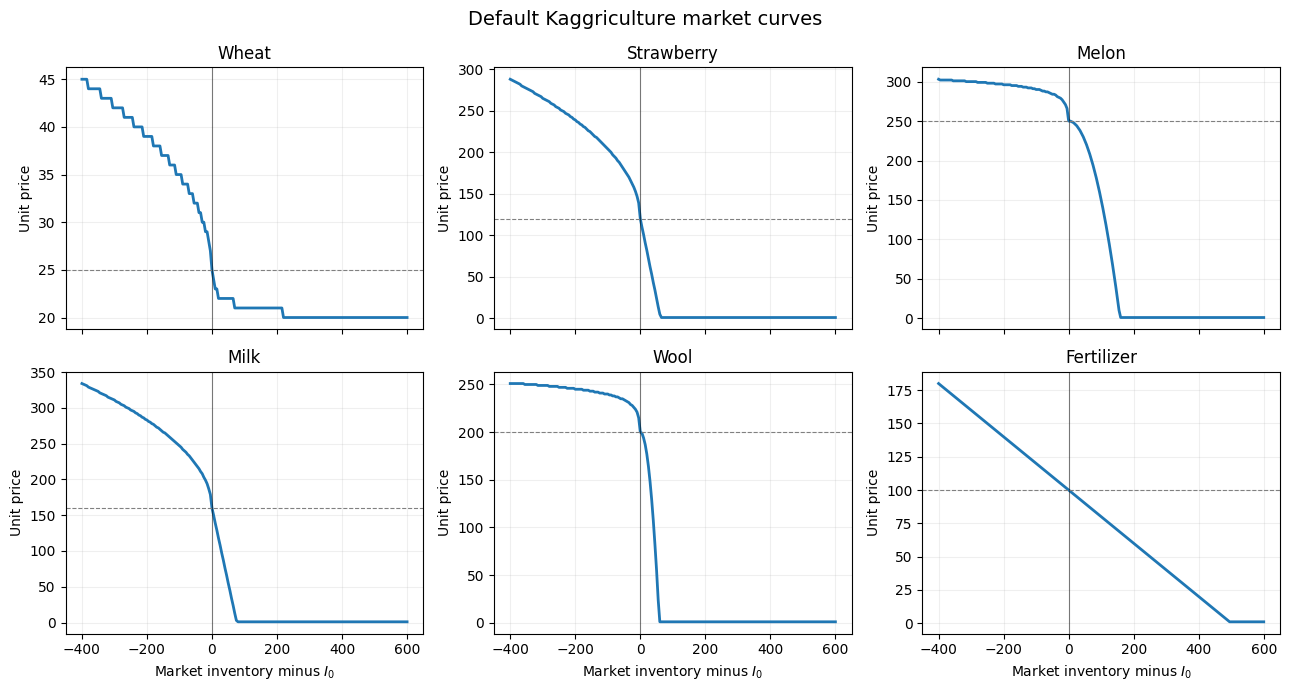

In [2]:
import math
import matplotlib.pyplot as plt
from IPython.display import display

CURVES = {
    "WHEAT": (25, 400, "sqrt", 0.80, "log", 0.20),
    "STRAWBERRY": (120, 100, "sqrt", 0.70, "linear", 1.60),
    "MELON": (250, 300, "log", 0.20, "sq", 3.60),
    "MILK": (160, 122, "sqrt", 0.60, "linear", 1.60),
    "WOOL": (200, 105, "log", 0.20, "sq", 3.20),
    "FERTILIZER": (100, 200, "linear", 0.40, "linear", 0.40),
}

def shape(name, value):
    value = max(0.0, float(value))
    if name == "linear":
        return value
    if name == "sq":
        return value * value
    if name == "sqrt":
        return math.sqrt(value)
    if name == "log":
        return math.log1p(value)
    if name == "log10":
        return math.log10(1.0 + value)
    raise ValueError(name)

def plotted_price(item, inventory):
    base, throughput, below_fn, below_move, above_fn, above_move = (
        CURVES[item]
    )
    if inventory < 10_000:
        amplitude = (
            below_move * base / shape(below_fn, throughput)
        )
        raw = (
            base
            + amplitude * shape(below_fn, 10_000 - inventory)
        )
    else:
        amplitude = (
            above_move * base / shape(above_fn, throughput)
        )
        raw = (
            base
            - amplitude * shape(above_fn, inventory - 10_000)
        )
    return max(1, round(raw))

inventory_deltas = list(range(-400, 601, 5))
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for axis, item in zip(axes.flat, CURVES):
    axis.plot(
        inventory_deltas,
        [
            plotted_price(item, 10_000 + delta)
            for delta in inventory_deltas
        ],
        linewidth=2,
    )
    axis.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    axis.axhline(
        CURVES[item][0],
        color="gray",
        linewidth=0.8,
        linestyle="--",
    )
    axis.set_title(item.title())
    axis.set_ylabel("Unit price")
    axis.grid(alpha=0.2)

for axis in axes[1]:
    axis.set_xlabel(r"Market inventory minus $I_0$")
fig.suptitle("Default Kaggriculture market curves", fontsize=14)
fig.tight_layout()
display(
    fig,
    metadata={
        "image/png": {
            "alt": (
                "Price curves for wheat, strawberry, melon, milk, "
                "wool, and fertilizer around equilibrium inventory."
            )
        }
    },
)
plt.close(fig)

### 3.1 Reservation price and liquidation flow

Selling too early sacrifices scarcity value; selling too late risks a
zero-value terminal balance. A product-specific reserve fraction
$\rho_r$ encodes tolerance for waiting. Fertilizer receives a low
reserve because it has no field value after collection; premium crop
and animal products retain product-specific thresholds. Three forces
relax every reserve: remaining time, shed pressure, and excess visible
supply.

| Product | Reserve fraction |
|---|---:|
| Wheat | 0.68 |
| Carrot | 0.55 |
| Tomato | 0.50 |
| Strawberry | 0.48 |
| Melon | 0.58 |
| Egg | 0.65 |
| Milk | 0.42 |
| Wool | 0.40 |
| Fertilizer | 0.18 |

$$
L=30-d,\qquad
C_{\text{shed}}
=\operatorname{configuration.shedCapacity},
\qquad
C_{\text{shed}}^{\text{default}}=100,
\qquad
s_t=\frac{\sum_r\widehat S_{r,t}}{C_{\text{shed}}}.
$$

$$
\theta_r^0(d,s_t)=\rho_rb_r
\times
\begin{cases}
  \max(0,(L-1)/6), & L\le 7,\\
  1, & L>7
\end{cases}
\times
\begin{cases}
  0.55, & s_t\ge 0.75,\\
  1, & s_t<0.75.
\end{cases}
$$

$$
g_r=
\left[
  \widehat Q_r^{-,\text{visible}}-D_r^{\text{town}}
\right]^+,
\qquad
\theta_r^1
=
\theta_r^0\max(0.72,1-0.015g_r).
$$

$$
\theta_r=
\begin{cases}
  \max\!\left(
    \theta_r^1,
    0.88p_r(\widehat I_{r,d+1}^{\text{heur}})
  \right),
  &s_t<0.75\land L>7,\\
  \theta_r^1,&\text{otherwise}.
\end{cases}
$$

With more than seven days and low storage pressure, the reserve also
includes 88% of the projected next-day price. This blocks a sale when
town drain is likely to improve the near-term market. The forecast
guard disappears under congestion or a short horizon because physical
conversion capacity becomes more valuable than speculative price
improvement.

$$
q_\theta
=
\max\left\{
  0\le q\le h_r:
  p_r(I+k)\ge\theta_r
  \;\forall k\in\{0,\ldots,q-1\}
\right\}.
$$

$$
q_{\text{floor}}=
\left\lceil\frac{h_r}{\max(1,L-1)}\right\rceil,
\qquad
q_r=
\begin{cases}
  q_\theta, & L>12,\\
  \min(h_r,\max(q_\theta,q_{\text{floor}})), & 1<L\le12,\\
  h_r, & L\le1.
\end{cases}
$$

$q_\theta$ sells only the marginal prefix above the current reserve.
The glide-path floor begins with 12 days remaining and submits at least
an approximately equal fraction of remaining stock at each decision
call while inventory remains.
The final day overrides price entirely. This converts liquidation from
a single terminal burst into a capacity-aware schedule while retaining
favorable price selectivity earlier in the season.

$$
h_{\text{wheat}}^{\text{sell}}
=
\begin{cases}
  \max(0,h_{\text{wheat}}-3N_{\text{animal pipeline}}), & L>2,\\
  h_{\text{wheat}}, & L\le2.
\end{cases}
$$

Wheat is both a sale product and operating inventory. Three units per
placed, stored, or carried animal are excluded from ordinary sale while
more than two days remain. The purchase rule also establishes an
eight-unit floor whenever the planned herd is nonempty. The reserve is
released during the last two days, when another feed cycle cannot
recover its opportunity cost.

## 4. Policy

Each turn follows a fixed causal order. Public and private state first
determine spatial roles. Tile state then expands those roles into jobs.
Worker assignment produces field actions, and market orders are
computed last. The shadow state replays `DROP`, product `PLACE`,
`PICKUP`, and `FEED` in unit execution order. This carries saleable
stock, shed capacity, and remaining wheat into market planning without
claiming to reproduce every field mutation.

$$
\pi_t:
o_t
\mapsto
(\phi_t,\mathcal R_t)
\mapsto
\mathcal J_t
\mapsto
\mathcal A_t
\mapsto
\mathcal M_t.
$$

$$
\pi_t=f(o_t),\qquad
\text{memory}=\varnothing,\qquad
\text{randomness}=\varnothing,\qquad
\text{external I/O}=\varnothing.
$$

Stateless recomputation makes identical observations produce identical
actions. Quadrant geometry fixes livestock and crop capacity. A placed
cow or sheep keeps its species; only empty future pasture slots respond
to current prices and visible herds. Existing crops outside the current
role map remain serviceable through an actual-tile scan.

### 4.1 Parameters

$$
\mathcal C_{\text{created}}
=\{\text{WHEAT},\text{CARROT},
\text{STRAWBERRY},\text{MELON}\},
\qquad
\mathcal A_{\text{created}}
=\{\text{COW},\text{SHEEP}\}.
$$

$$
U_t=1+N_{\text{hands},t},
\qquad
N_t^{\text{risk}}
=N_t^{\text{animal prior miss}}
+N_t^{\text{crop prior miss}},
\qquad
\Delta_t=719-t.
$$

$$
\phi_t=
\begin{cases}
  \text{LIQUIDATE},&\Delta_t\le38,\\
  \text{CRISIS},
  &N_t^{\text{risk}}>U_t
   \lor Q_t^{\text{shed}}+Q_t^{\text{carry}}\ge95,\\
  \text{BOOTSTRAP},&d_t\le4,\\
  \text{COMPOUND},&5\le d_t\le21,\\
  \text{REALIZE},&d_t\ge22.
\end{cases}
$$

Phase precedence is intentional. Liquidation overrides every other
state because terminal feasibility is irreversible. Crisis overrides
calendar phases when endangered assets exceed available workers or
aggregate shed-plus-carried load reaches 95. Calendar phases apply only
after both safety checks pass.

| State | Production and capital | Inventory |
|---|---|---|
| Crisis | Ranked jobs; no land; conditional livestock | Price-gated sales; pressure unload |
| Bootstrap | Core cow–sheep herd, bounded melon, 10-hand floor | Feed floor; no land purchase before day 5 |
| Compound | Herd stages 8 and 12; land on days 5 and 9; strawberry expansion | Feed floor; forecast-timed sales |
| Realize | Cutoff-feasible crop cycles; no land or livestock purchase | Sale glide path |
| Liquidate | Screened terminal jobs; salvage labor only | Return, unload, final sale |

| Observable condition | Response |
|---|---|
| Prior missed water or feed | Priority 0 loss prevention |
| Shed + carried load at least 95 | Crisis capital gate and accelerated unload |
| Crop-only crisis; load below 95; prepared pasture exceeds pipeline | Keep livestock capital open |
| Rival melon at least 12, or price at most 170 | Melon target becomes 8 |
| Visible rival supply exceeds town drain | Lower sale reserve; sell earlier |
| Wheat below three per pipeline animal or startup floor | Buy wheat after livestock orders |
| Day 5 with at least 1,300 planning cash | Buy the first expansion |
| Day 9 with at least 2,500 planning cash | Buy the second expansion |
| Carried products at least 20 units or value at least 2,500 | Create a batch-unload mission |
| 38 or fewer actions remain | Reject production capital; allow cash-feasible recovery only |

Bootstrap allocates initial cash among two cows, two sheep, feed,
melon seed, and early labor. Land purchases are delayed to days 5 and
9, after the first quadrant has begun converting cash. Compound raises
the herd target to eight and then twelve while two expansions add
strawberry capacity. Realize stops land and livestock growth, while
crop roles remain subject to their individual planting cutoffs.

Crisis is not a wholesale shutdown of field work. Existing jobs remain
available, but loss-prevention bonuses make missed feed and water win
assignment. Land remains blocked in crisis. Livestock capital is an
explicit exception when no animal is at risk, aggregate load remains
below 95, and an already built empty structure has capacity beyond the
owned pipeline. Prepared pasture can then be filled even when crop
workload alone triggers crisis. Storage uses a two-level response: load
80 accelerates worker return, and load 95 closes the exception as well
as activating the hard capital gate.

Liquidation replaces ordinary growth with a Manhattan lower-bound
feasibility screen. A terminal job remains a candidate only when
nominal travel to the asset, the field action, return travel, and
unloading fit before the final action. BFS reachability, worker
competition, shed capacity, and market-order availability remain
separate constraints.
Harvest and fertilizer collection may be assigned to different workers
on the same animal tile during liquidation because they are distinct
cash-recovery operations.
Under the default 720-state configuration, the 38-action window begins
at step 681, or day 28 hour 9. A last-action `DROP` can be followed by a
same-turn `SELL`, but `HARVEST` cannot also unload in that field action.
The final sale ignores reservation price.

In [3]:
%%agentfile
"""Deterministic scenario-aware economic policy for Kaggriculture."""

from collections import deque
import math


# Domain constants

CROPS = {
    "WHEAT": {
        "seed": 10,
        "first": 2,
        "max_day": 4,
        "max_yield": 6,
        "ongoing": False,
        "ripe": 4,
        "last_plant": 24,
    },
    "CARROT": {
        "seed": 20,
        "first": 2,
        "max_day": 3,
        "max_yield": 4,
        "ongoing": False,
        "ripe": 3,
        "last_plant": 25,
    },
    "TOMATO": {
        "seed": 50,
        "first": 8,
        "max_day": 8,
        "max_yield": 4,
        "ongoing": True,
        "ripe": 8,
        "last_plant": 19,
    },
    "STRAWBERRY": {
        "seed": 100,
        "first": 10,
        "max_day": 10,
        "max_yield": 4,
        "ongoing": True,
        "ripe": 10,
        "last_plant": 18,
    },
    "MELON": {
        "seed": 80,
        "first": 10,
        "max_day": 12,
        "max_yield": 6,
        "ongoing": False,
        "ripe": 10,
        "last_plant": 18,
    },
}

ANIMALS = {
    "GOOSE": {
        "cost": 300,
        "structure": "COOP",
        "product": "EGG",
        "first": 4,
        "interval": 1,
        "max_held": 4,
    },
    "COW": {
        "cost": 400,
        "structure": "PASTURE",
        "product": "MILK",
        "first": 8,
        "interval": 2,
        "max_held": 6,
    },
    "SHEEP": {
        "cost": 500,
        "structure": "PASTURE",
        "product": "WOOL",
        "first": 6,
        "interval": 3,
        "max_held": 6,
    },
}

PRODUCTS = (
    "WHEAT",
    "CARROT",
    "TOMATO",
    "STRAWBERRY",
    "MELON",
    "EGG",
    "MILK",
    "WOOL",
    "FERTILIZER",
)

MARKET = {
    "WHEAT": (25, 400, "sqrt", 0.80, "log", 0.20),
    "CARROT": (35, 450, "log", 0.20, "sqrt", 0.70),
    "TOMATO": (60, 200, "linear", 0.40, "sqrt", 0.60),
    "STRAWBERRY": (120, 100, "sqrt", 0.70, "linear", 1.60),
    "MELON": (250, 300, "log", 0.20, "sq", 3.60),
    "EGG": (50, 332, "linear", 0.40, "log", 0.20),
    "MILK": (160, 122, "sqrt", 0.60, "linear", 1.60),
    "WOOL": (200, 105, "log", 0.20, "sq", 3.20),
    "FERTILIZER": (100, 200, "linear", 0.40, "linear", 0.40),
}

SHOPS = {
    "BAKERY": ("EGG", "WHEAT"),
    "PIZZA_SHOP": ("MILK", "TOMATO", "WHEAT"),
    "BRUNCH_SPOT": ("EGG", "WHEAT", "STRAWBERRY"),
    "YARN_STORE": ("WOOL",),
    "ICE_CREAM_SHOP": ("STRAWBERRY", "MILK", "WHEAT"),
    "PET_CAFE": ("CARROT",),
    "SMOOTHIE_SHOP": ("STRAWBERRY", "MILK"),
    "FARMERS_MARKET": ("WHEAT", "CARROT", "TOMATO", "STRAWBERRY"),
}

RESERVE_FRACTION = {
    "WHEAT": 0.68,
    "CARROT": 0.55,
    "TOMATO": 0.50,
    "STRAWBERRY": 0.48,
    "MELON": 0.58,
    "EGG": 0.65,
    "MILK": 0.42,
    "WOOL": 0.40,
    "FERTILIZER": 0.18,
}

MOVES = (
    ("NORTH", 0, -1),
    ("WEST", -1, 0),
    ("SOUTH", 0, 1),
    ("EAST", 1, 0),
)

LAND_PRICES = (1000, 2000, 4000)
MARKET_I0 = 10000
TOTAL_DAYS = 30
MAX_MARKET_ORDERS = 10
MAX_HANDS = 12
CORE_HERD = 4
MID_HERD = 8
TARGET_HERD = 12
HERD_EXPANSION_DAY = 7
HERD_FINAL_DAY = 11
ANIMAL_PURCHASE_LAST_DAY = 18
ANIMAL_SLOTS = {"NW": 4, "NE": 5, "SW": 3, "SE": 0}
CROP_MIX = {
    "NW": {"MELON": 10, "WHEAT": 4, "CARROT": 2},
    "NE": {"WHEAT": 4, "CARROT": 1},
    "SW": {"WHEAT": 4, "CARROT": 1},
    "SE": {"WHEAT": 5, "CARROT": 2},
}
MELON_TILES_MIN = 8
MELON_TILES_BASE = 10
MELON_TILES_MAX = 12
MAX_EXTRA_LAND = 2
CASH_RESERVE = 250
LIQUIDATION_TURNS = 38
SHED_CAPACITY = 100
TRAVEL_COST = 8.0
FEED_STOCK_DAYS = 3
LAND_OPEN_DAYS = (5, 9)
PRIORITY_BONUS = {
    -1: 120_000.0,
    0: 100_000.0,
    1: 1_500.0,
    2: 750.0,
    3: 250.0,
    4: 0.0,
    5: -100.0,
}


# Configuration, pricing, and routing helpers



### 4.2 Geometry and routing

The four central shed coordinates are not equally usable when only part
of the board is unlocked. Routing therefore filters the set before any
distance calculation. A worker never targets a locked shed entrance,
preventing repeated `PASS` actions at an unreachable central tile.

$$
\mathcal S=
\{(h-1,h-1),(h,h-1),(h-1,h),(h,h)\},
\qquad
h=\left\lfloor\frac{N_{\text{board}}}{2}\right\rfloor.
$$

$$
\mathcal S_t^{+}
=
\{s\in\mathcal S:\operatorname{tile}_t(s)\ne\texttt{LOCKED}\}.
$$

$$
d_S(x)=
\min_{(s_x,s_y)\in\mathcal S_t^+}
\left(|x-s_x|+|y-s_y|\right).
$$

$$
a_t^u=
\operatorname{first}
\left(
  \operatorname{BFS}
  (u_t,z,\;\text{tiles}\ne\texttt{LOCKED})
\right).
$$

$$
\text{tie order}=
(\texttt{NORTH},\texttt{WEST},\texttt{SOUTH},\texttt{EAST}).
$$

Manhattan distance supplies a cheap shadow cost for role ordering and
worker scoring. Legal movement is still produced by BFS over unlocked
tiles, so obstacles cannot invalidate the chosen first step. Fixed
neighbor order makes equal-length routes deterministic.

Within each unlocked quadrant, the nearest cells are reserved for
livestock: four in NW, five in NE, three in SW, and none in SE. Animal
work creates daily feed plus repeated care, harvest, and fertilizer
trips, so recurring route savings compound across the season. Remaining
cells retain deterministic distance order for crop assignment. A placed
animal overrides a newly computed species target, preserving sunk
construction and transport.

In [4]:
%%agentfile append
def _cfg(config, key, default):
    if config is None:
        return default
    if isinstance(config, dict):
        return config.get(key, default)
    return getattr(config, key, default)


def _shape(name, value):
    value = max(0.0, float(value))
    if name == "linear":
        return value
    if name == "sq":
        return value * value
    if name == "sqrt":
        return math.sqrt(value)
    if name == "log":
        return math.log1p(value)
    if name == "log10":
        return math.log10(1.0 + value)
    return value


def _market_parameters(obs, item):
    base, throughput, below_fn, below_move, above_fn, above_move = MARKET[item]
    custom = (((obs or {}).get("market", {}) or {}).get("params", {}) or {}).get(
        item, {}
    )
    return (
        float(custom.get("base", base)),
        float(custom.get("T", throughput)),
        str(custom.get("below_func", below_fn)),
        float(custom.get("below_target", below_move)),
        str(custom.get("above_func", above_fn)),
        float(custom.get("above_target", above_move)),
        float(custom.get("I0", MARKET_I0)),
    )


def _price_at(item, inventory, obs=None):
    (
        base,
        throughput,
        below_fn,
        below_move,
        above_fn,
        above_move,
        equilibrium,
    ) = _market_parameters(obs, item)
    if inventory < equilibrium:
        amplitude = below_move * base / max(1e-9, _shape(below_fn, throughput))
        value = base + amplitude * _shape(below_fn, equilibrium - inventory)
    else:
        amplitude = above_move * base / max(1e-9, _shape(above_fn, throughput))
        value = base - amplitude * _shape(above_fn, inventory - equilibrium)
    return max(1, int(round(value)))


def _town_demand_per_day(obs, item):
    day = int((obs or {}).get("day", 0) or 0)
    center = 0 if item == "FERTILIZER" else 2 * (
        4 if day >= 20 else 2 if day >= 10 else 1
    )
    shop = 0
    for name in (((obs or {}).get("town", {}) or {}).get(
        "unlocked_shops", []
    ) or []):
        products = SHOPS.get(name, ())
        if item in products:
            shop += 12 if len(products) == 1 else 6
    return center + shop


def _opponent_visible_supply(obs, item, horizon=1):
    player = int((obs or {}).get("player", 0) or 0)
    day = int((obs or {}).get("day", 0) or 0)
    animal_for = {"EGG": "GOOSE", "MILK": "COW", "WOOL": "SHEEP"}
    total = 0
    for index, farm in enumerate((obs or {}).get("farms", []) or []):
        if index == player:
            continue
        for row in farm.get("tiles", []) or []:
            for tile in row:
                if not isinstance(tile, dict):
                    continue
                if (
                    item in CROPS
                    and tile.get("kind") == "PLANT"
                    and tile.get("crop") == item
                ):
                    rule = CROPS[item]
                    planted = tile.get("planted_day")
                    planted_day = day if planted is None else int(planted)
                    age = day - planted_day
                    held = int(tile.get("yield_units", 0) or 0)
                    if held > 0 and age >= rule["first"]:
                        total += held
                    elif age + horizon >= rule["ripe"]:
                        total += max(1, min(rule["max_yield"], held + horizon))
                elif item in animal_for and tile.get("animal") == animal_for[item]:
                    total += int(tile.get("yield_units", 0) or 0)
                    if horizon > 0:
                        total += min(2 * horizon, ANIMALS.get(
                            tile.get("animal"), {"max_held": 4}
                        )["max_held"])
    return total


def _distance(a, b):
    return abs(int(a[0]) - int(b[0])) + abs(int(a[1]) - int(b[1]))


def _shed_tiles(board_size, tiles=None):
    half = board_size // 2
    candidates = (
        (half - 1, half - 1),
        (half, half - 1),
        (half - 1, half),
        (half, half),
    )
    if tiles is None:
        return candidates
    accessible = tuple(
        position
        for position in candidates
        if tiles[position[1]][position[0]] != "LOCKED"
    )
    return accessible or candidates[:1]


def _nearest_shed(position, board_size, tiles=None):
    return min(
        _shed_tiles(board_size, tiles),
        key=lambda target: (_distance(position, target), target[1], target[0]),
    )


def _bfs_first_step(tiles, source, target):
    source = (int(source[0]), int(source[1]))
    target = (int(target[0]), int(target[1]))
    if source == target:
        return ["PASS"]
    board_size = len(tiles)
    queue = deque([source])
    parent = {source: None}
    parent_move = {}
    while queue:
        current = queue.popleft()
        if current == target:
            break
        for name, dx, dy in MOVES:
            nxt = (current[0] + dx, current[1] + dy)
            if not (0 <= nxt[0] < board_size and 0 <= nxt[1] < board_size):
                continue
            if nxt in parent or tiles[nxt[1]][nxt[0]] == "LOCKED":
                continue
            parent[nxt] = current
            parent_move[nxt] = name
            queue.append(nxt)
    if target not in parent:
        return ["PASS"]
    current = target
    while parent[current] != source:
        current = parent[current]
        if current is None:
            return ["PASS"]
    return [parent_move[current]]


def _melon_target(obs):
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    price = int(prices.get("MELON", MARKET["MELON"][0]) or MARKET["MELON"][0])
    opponent_tiles = 0
    player = int(obs.get("player", 0) or 0)
    for index, other in enumerate(obs.get("farms", []) or []):
        if index == player:
            continue
        for row in other.get("tiles", []) or []:
            opponent_tiles += sum(
                isinstance(tile, dict)
                and tile.get("kind") == "PLANT"
                and tile.get("crop") == "MELON"
                for tile in row
            )
    if price >= 300 and opponent_tiles <= 5:
        return MELON_TILES_MAX
    if price <= 170 or opponent_tiles >= 12:
        return MELON_TILES_MIN
    if opponent_tiles >= 9:
        return MELON_TILES_BASE - 1
    return MELON_TILES_BASE


def _private_item_total(private, item):
    total = int((private.get("shed", {}) or {}).get(item, 0) or 0)
    for inventory in private.get("inventories", []) or []:
        total += int((inventory or {}).get(item, 0) or 0)
    return total


def _farm_animal_counts(farm):
    counts = {animal: 0 for animal in ANIMALS}
    for row in farm.get("tiles", []) or []:
        for tile in row:
            if isinstance(tile, dict) and tile.get("animal") in counts:
                counts[tile["animal"]] += 1
    return counts


def _opponent_animal_counts(obs):
    player = int(obs.get("player", 0) or 0)
    counts = {animal: 0 for animal in ANIMALS}
    for index, farm in enumerate(obs.get("farms", []) or []):
        if index == player:
            continue
        visible = _farm_animal_counts(farm)
        for animal, count in visible.items():
            counts[animal] += count
    return counts


def _livestock_score(obs, animal, own_count, opponent_count):
    rule = ANIMALS[animal]
    product = rule["product"]
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    price = float(prices.get(product, MARKET[product][0]) or MARKET[product][0])
    normalized_price = price / float(MARKET[product][0])
    demand_support = 1.0 + 0.012 * _town_demand_per_day(obs, product)
    crowding = 1.0 + 0.18 * opponent_count + 0.08 * own_count
    return normalized_price * demand_support / crowding


def _quadrant_of(position, board_size):
    x, y = position
    half = board_size // 2
    return ("N" if y < half else "S") + ("W" if x < half else "E")


def _reserved_animal_slots(farm):
    tiles = farm.get("tiles", []) or []
    board_size = len(tiles)
    unlocked = set(farm.get("unlocked_quadrants", []) or ["NW"])
    sheds = _shed_tiles(board_size, tiles)
    slots = []
    by_quadrant = {}
    for quadrant in ("NW", "NE", "SW", "SE"):
        if quadrant not in unlocked:
            continue
        cells = []
        for y, row in enumerate(tiles):
            for x, tile in enumerate(row):
                if tile == "LOCKED" or _quadrant_of((x, y), board_size) != quadrant:
                    continue
                distance = min(_distance((x, y), shed) for shed in sheds)
                cells.append((distance, y, x))
        cells.sort()
        count = min(ANIMAL_SLOTS[quadrant], len(cells))
        selected = [(x, y) for _, y, x in cells[:count]]
        by_quadrant[quadrant] = {
            "reserved": selected,
            "crops": [(x, y) for _, y, x in cells[count:]],
        }
        slots.extend(selected)
    return slots, by_quadrant


def _herd_targets(obs, farm, private, capacity):
    day = int(obs.get("day", 0) or 0)
    left = TOTAL_DAYS - day
    placed = _farm_animal_counts(farm)
    owned = {
        animal: placed[animal] + _private_item_total(private, animal)
        for animal in ("COW", "SHEEP")
    }
    if day < HERD_EXPANSION_DAY:
        stage_target = CORE_HERD
    elif day < HERD_FINAL_DAY:
        stage_target = MID_HERD
    else:
        stage_target = TARGET_HERD
    if day > ANIMAL_PURCHASE_LAST_DAY or left < 8:
        stage_target = sum(owned.values())
    target_total = min(capacity, max(sum(owned.values()), stage_target))

    targets = {
        "COW": max(2 if target_total >= CORE_HERD else 0, owned["COW"]),
        "SHEEP": max(2 if target_total >= CORE_HERD else 0, owned["SHEEP"]),
    }
    opponents = _opponent_animal_counts(obs)
    while sum(targets.values()) < target_total:
        animal = max(
            ("COW", "SHEEP"),
            key=lambda name: (
                _livestock_score(
                    obs,
                    name,
                    targets[name],
                    opponents[name],
                ),
                -targets[name],
                name == "COW",
            ),
        )
        targets[animal] += 1
    return targets




### 4.3 Spatial roles and job generation

Role allocation separates long-lived spatial intent from the action
required by the current tile state. A crop role can generate `DIG`,
`PLANT`, `WATER`, or `HARVEST`; an animal role can generate
`BUILD_PASTURE`, `PLACE`, `FEED`, `CARE`, `HARVEST`, or
`COLLECT_FERTILIZER`. This separation expresses intended land use while
the scheduler reacts to daily tile state.

$$
(c_{q,0},\ldots,c_{q,K_q-1})
=
\operatorname{sort}
\left(C_q;\;d_S,y,x\right),
\qquad q\in\{\mathrm{NW},\mathrm{NE},\mathrm{SW},\mathrm{SE}\}.
$$

$$
\left(A_{\mathrm{NW}},A_{\mathrm{NE}},A_{\mathrm{SW}},A_{\mathrm{SE}}\right)
=(4,5,3,0),
\qquad
\mathcal R_{q}^{\text{animal}}
=\operatorname{First}_{A_q}(c_{q,0},\ldots,c_{q,K_q-1}).
$$

$$
A_t^*=\min\!\left(
  \sum_{q\in Q_t}A_q,\;G_t^*
\right),
\qquad
\mathcal R_t^{\text{animal}}
=\operatorname{First}_{A_t^*}
  \left(\mathcal R_{\mathrm{NW}}^{\text{animal}},
  \mathcal R_{\mathrm{NE}}^{\text{animal}},
  \mathcal R_{\mathrm{SW}}^{\text{animal}}\right).
$$

The active livestock list follows quadrant order and grows only when
land unlocks and the staged herd target increases. The first four slots
receive cow, cow, sheep, sheep. Later empty slots consume the remaining
species deficits. A placed cow or sheep always overrides a new target,
so market signals affect future capacity without rewriting sunk assets.

$$
\begin{aligned}
\mathcal R_{\mathrm{NW}}^{\text{crop}}
  &: \underbrace{M_t\times\text{MELON}}_{8\text{--}12},
     \;\text{residual STRAWBERRY},
     \;4\times\text{WHEAT},
     \;2\times\text{CARROT},\\
\mathcal R_{\mathrm{NE}}^{\text{crop}}
  &: \text{residual STRAWBERRY},
     \;4\times\text{WHEAT},
     \;1\times\text{CARROT},\\
\mathcal R_{\mathrm{SW}}^{\text{crop}}
  &: \text{residual STRAWBERRY},
     \;4\times\text{WHEAT},
     \;1\times\text{CARROT}.
\end{aligned}
$$

$$
\operatorname{tile}_t(x)\in\{\text{PLANT},\text{ANIMAL}\}
\Rightarrow
x\in\operatorname{dom}(\mathcal J_t)
\quad\text{independent of }\mathcal R_t.
$$

Existing crops and animals remain eligible to generate state-dependent
jobs even when a newly computed zone would assign a different future
role. They are not silently removed from consideration after market
conditions or unlocked land change the role map; actual service still
depends on labor, routing, inventory, and competing jobs.

| Priority | Bonus | Jobs |
|---:|---:|---|
| -1 | 120,000 | terminal unload |
| 0 | 100,000 | second-miss water/feed; terminal harvest/fertilizer |
| 1 | 1,500 | ordinary feed; final growth water; place livestock |
| 2 | 750 | ripe harvest; clear animal slot; fertilizer; batch unload |
| 3 | 250 | yield-window water; care; build or replace pasture |
| 4 | 0 | plant; dig |

Priority bonuses encode irreversibility, while $V_j$ ranks jobs inside
a priority band. Representative values are:

$$
\begin{aligned}
V_{\text{harvest}}&=q_jp_j,\\
V_{\text{critical water}}
  &=p_j\max(q_j,0.7Y_j^{\max}),\\
V_{\text{plant}}
  &=\max(40,0.65\,\widehat y_jp_j-c_j),\\
V_{\text{drop}}
  &=\max(120,0.22\,V_{\text{carried cash}}).
\end{aligned}
$$

Critical feed uses $V_j=900$, ordinary feed $260$, livestock placement
$900$, pasture construction $420$, incompatible-structure replacement
$250$, and weed removal $120$ while more than five days remain. Under
default-scale prices, the $100{,}000$ critical
bonus is intended to dominate ordinary jobs because preventing
destruction of funded assets usually exceeds a spot-market timing gain.
Priorities 1--4 are soft bands: a sufficiently large $V_j$ can
cross a nominal priority gap. This lets a large realized harvest beat a
weak routine task, while value and distance still resolve comparable
choices.

| Crop state | Action |
|---|---|
| One-time; outside bonus window; no prior miss | defer water |
| One-time; inside bonus window; unwatered | water |
| Any crop; one prior miss; unwatered | water with priority 0 |
| One-time; ripe; bonus window; unwatered; below cap | final growth water |
| One-time; ripe otherwise | harvest |
| Ongoing; age at least first yield minus 1; unwatered | water |
| Ongoing; held stock at least max yield minus 1 | harvest |
| Ongoing; positive stock; day 27+ | harvest |

One-time crops defer water before the bonus window, water during the
productive window, and take one last productive water action before a
ripe harvest when capacity remains. Ongoing crops are watered from one
day before the first-yield boundary and harvested near their holding
cap or from day 27 onward. Any previous miss bypasses these marginal
comparisons and enters priority 0.

$$
h_t+d(u,x)\le22
\quad
\forall x\in
\mathcal J_t^{\text{PLANT}}\cup
\mathcal J_t^{\mathrm{BUILD}_{\mathrm{PASTURE}}}.
$$

The hour-22 arrival constraint prevents a worker from traveling toward
a target that cannot legally receive construction or planting before
the daily boundary. Crop-specific last-plant dates add a second horizon
gate based on maturation time. Together they remove many jobs with
insufficient nominal maturation time, without claiming full future
service, harvest, return, or sale feasibility.

In [5]:
%%agentfile append
def _role_plan(obs, farm):
    private = obs.get("private", {}) or {}
    tiles = farm.get("tiles", []) or []
    animal_slots, zones = _reserved_animal_slots(farm)
    targets = _herd_targets(obs, farm, private, len(animal_slots))
    desired_animals = min(len(animal_slots), sum(targets.values()))
    active_slots = list(animal_slots[:desired_animals])
    for position in animal_slots:
        x, y = position
        tile = tiles[y][x]
        if isinstance(tile, dict) and "animal" in tile and position not in active_slots:
            active_slots.append(position)

    assigned = {"COW": 0, "SHEEP": 0}
    roles = {}
    core_sequence = ("COW", "COW", "SHEEP", "SHEEP")
    for index, position in enumerate(active_slots):
        x, y = position
        tile = tiles[y][x]
        actual = tile.get("animal") if isinstance(tile, dict) else None
        if actual in assigned:
            animal = actual
        elif index < len(core_sequence) and assigned[core_sequence[index]] < targets[
            core_sequence[index]
        ]:
            animal = core_sequence[index]
        else:
            animal = max(
                ("COW", "SHEEP"),
                key=lambda name: (
                    targets[name] - assigned[name],
                    _private_item_total(private, name),
                    name == "COW",
                ),
            )
        roles[position] = ("ANIMAL", animal)
        assigned[animal] += 1

    melon_target = _melon_target(obs)
    for quadrant in ("NW", "NE", "SW", "SE"):
        zone = zones.get(quadrant)
        if not zone:
            continue
        cells = zone["crops"]
        fixed = dict(CROP_MIX[quadrant])
        if quadrant == "NW":
            fixed["MELON"] = min(melon_target, len(cells))
        strawberry_count = max(0, len(cells) - sum(fixed.values()))
        sequence = []
        if quadrant == "NW":
            sequence.extend(["MELON"] * fixed.get("MELON", 0))
        sequence.extend(["STRAWBERRY"] * strawberry_count)
        sequence.extend(["WHEAT"] * fixed.get("WHEAT", 0))
        sequence.extend(["CARROT"] * fixed.get("CARROT", 0))
        if quadrant != "NW":
            sequence.extend(["MELON"] * fixed.get("MELON", 0))
        for position, crop in zip(cells, sequence):
            roles[position] = ("CROP", crop)
    return roles


# Observation summaries and job generation

def _inventory_total(inventory, excluded=()):
    return sum(
        int(value)
        for item, value in (inventory or {}).items()
        if item not in excluded and isinstance(value, (int, float)) and value > 0
    )


def _survey(farm, private, roles=None, day=0):
    summary = {
        "animals": 0,
        "unfed": 0,
        "at_risk_animals": 0,
        "at_risk_crops": 0,
        "open_structures": 0,
        "structures_todo": 0,
        "plants": 0,
        "plantable": 0,
        "weeds": 0,
    }
    for row in farm.get("tiles", []) or []:
        for tile in row:
            if not isinstance(tile, dict):
                continue
            if "animal" in tile:
                summary["animals"] += 1
                if not tile.get("fed_today", False):
                    summary["unfed"] += 1
                if int(tile.get("consecutive_unfed", 0) or 0) >= 1:
                    summary["at_risk_animals"] += 1
            elif tile.get("kind") in {"COOP", "PASTURE"}:
                summary["open_structures"] += 1
            elif tile.get("kind") == "PLANT":
                summary["plants"] += 1
                if int(tile.get("consecutive_unwatered", 0) or 0) >= 1:
                    summary["at_risk_crops"] += 1
            elif tile.get("kind") == "WEED":
                summary["weeds"] += 1

    if roles:
        for (x, y), (kind, item) in roles.items():
            tile = farm["tiles"][y][x]
            if kind == "ANIMAL" and tile is None:
                summary["structures_todo"] += 1
            elif (
                kind == "CROP"
                and tile is None
                and day <= CROPS[item]["last_plant"]
            ):
                summary["plantable"] += 1

    summary["wheat_stock"] = int((private.get("shed", {}) or {}).get("WHEAT", 0))
    summary["animal_stock"] = {
        animal: int((private.get("shed", {}) or {}).get(animal, 0) or 0)
        for animal in ANIMALS
    }
    summary["shed_load"] = sum(
        max(0, int(value or 0))
        for value in (private.get("shed", {}) or {}).values()
    )
    summary["carried_load"] = 0
    for inventory in private.get("inventories", []) or []:
        summary["wheat_stock"] += int((inventory or {}).get("WHEAT", 0))
        for animal in ANIMALS:
            summary["animal_stock"][animal] += int(
                (inventory or {}).get(animal, 0) or 0
            )
        summary["carried_load"] += _inventory_total(inventory)
    return summary


def _policy_phase(obs, farm, private, summary):
    day = int(obs.get("day", 0) or 0)
    step = int(obs.get("step", day * 24 + int(obs.get("hour", 0) or 0)) or 0)
    actions_left = max(0, 719 - step)
    if actions_left <= LIQUIDATION_TURNS:
        return "LIQUIDATE"
    workers = 1 + len(farm.get("hands", []) or [])
    if (
        summary["at_risk_animals"] + summary["at_risk_crops"] > workers
        or summary["shed_load"] + summary["carried_load"] >= 95
    ):
        return "CRISIS"
    if day <= 4:
        return "BOOTSTRAP"
    if day <= 21:
        return "COMPOUND"
    return "REALIZE"


def _add_job(
    jobs,
    priority,
    value,
    target,
    action,
    need=None,
    reason="",
    latest_hour=23,
):
    jobs.append(
        {
            "priority": int(priority),
            "value": float(value),
            "target": tuple(target),
            "action": list(action),
            "need": need,
            "reason": str(reason),
            "latest_hour": int(latest_hour),
        }
    )


def _animal_produces_tonight(tile, rule, day):
    next_day = int(day) + 1
    placed_day = int(tile.get("placed_day", day) or 0)
    days_since_first = next_day - placed_day - int(rule["first"])
    return (
        days_since_first >= 0
        and days_since_first % int(rule["interval"]) == 0
    )


def _crop_jobs(obs, jobs, tile, target, day, liquidation):
    crop = tile.get("crop")
    rule = CROPS.get(crop)
    if rule is None:
        return
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    price = float(prices.get(crop, MARKET[crop][0]) or MARKET[crop][0])
    age = day - int(tile.get("planted_day", day))
    amount = int(tile.get("yield_units", 0) or 0)
    watered = bool(tile.get("watered_today", False))
    drought = int(tile.get("consecutive_unwatered", 0) or 0)
    critical = drought >= 1

    if liquidation:
        if amount > 0 and age >= rule["first"]:
            _add_job(
                jobs,
                0,
                amount * price,
                target,
                ("HARVEST",),
                reason="terminal_harvest",
            )
        return

    if critical and not watered:
        protected = max(amount, rule["max_yield"] * 0.7) * price
        _add_job(
            jobs,
            0,
            protected,
            target,
            ("WATER",),
            reason="critical_water",
        )
        return

    if rule["ongoing"]:
        if amount >= rule["max_yield"] - 1 or (amount > 0 and day >= 27):
            _add_job(
                jobs,
                2,
                amount * price,
                target,
                ("HARVEST",),
                reason="ongoing_harvest",
            )
        elif not watered and age >= rule["first"] - 1:
            _add_job(
                jobs,
                3,
                price,
                target,
                ("WATER",),
                reason="ongoing_water",
            )
        return

    ripe = age >= rule["ripe"] and amount > 0
    in_growth_window = (rule["max_day"] + 1) // 2 <= age <= rule["max_day"]
    if ripe:
        if in_growth_window and not watered and amount < rule["max_yield"]:
            _add_job(
                jobs,
                1,
                price,
                target,
                ("WATER",),
                reason="final_growth_water",
            )
        else:
            _add_job(
                jobs,
                2,
                amount * price,
                target,
                ("HARVEST",),
                reason="ripe_harvest",
            )
    elif in_growth_window and not watered:
        _add_job(
            jobs,
            3,
            price,
            target,
            ("WATER",),
            reason="yield_water",
        )


def _field_jobs(obs, farm, private, roles, liquidation):
    day = int(obs.get("day", 0) or 0)
    hour = int(obs.get("hour", 0) or 0)
    left = TOTAL_DAYS - day
    tiles = farm["tiles"]
    seeds = dict(private.get("seeds", {}) or {})
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    jobs = []
    planned_roles = dict(roles)
    for y, row in enumerate(tiles):
        for x, tile in enumerate(row):
            if not isinstance(tile, dict) or (x, y) in planned_roles:
                continue
            if tile.get("kind") == "PLANT" and tile.get("crop") in CROPS:
                planned_roles[(x, y)] = ("CROP", tile["crop"])
            elif tile.get("animal") in ANIMALS:
                planned_roles[(x, y)] = ("ANIMAL", tile["animal"])

    for target, role in planned_roles.items():
        x, y = target
        tile = tiles[y][x]
        role_kind, role_item = role

        if tile is None:
            if liquidation:
                continue
            if role_kind == "ANIMAL":
                animal_rule = ANIMALS[role_item]
                if left >= animal_rule["first"] + 2:
                    _add_job(
                        jobs,
                        3,
                        420,
                        target,
                        ("BUILD_" + animal_rule["structure"],),
                        reason="build_" + animal_rule["structure"].lower(),
                        latest_hour=22,
                    )
            elif (
                hour <= 22
                and day <= CROPS[role_item]["last_plant"]
                and seeds.get(role_item, 0) > 0
            ):
                rule = CROPS[role_item]
                expected = 4 if role_item == "WHEAT" else rule["max_yield"]
                price = float(
                    prices.get(role_item, MARKET[role_item][0])
                    or MARKET[role_item][0]
                )
                value = max(40, 0.65 * expected * price - rule["seed"])
                _add_job(
                    jobs,
                    4,
                    value,
                    target,
                    ("PLANT", role_item),
                    reason="plant_" + role_item,
                    latest_hour=22,
                )
            continue

        if not isinstance(tile, dict):
            continue
        kind = tile.get("kind")
        if role_kind == "ANIMAL" and kind in {"WEED", "PLANT"}:
            if not liquidation:
                _add_job(
                    jobs,
                    2,
                    500,
                    target,
                    ("DIG",),
                    reason="clear_animal_slot",
                    latest_hour=22,
                )
            continue
        if kind == "WEED":
            if not liquidation:
                _add_job(
                    jobs,
                    4,
                    120 if left > 5 else 10,
                    target,
                    ("DIG",),
                    reason="dig_weed",
                    latest_hour=22,
                )
            continue
        if kind == "PLANT":
            _crop_jobs(obs, jobs, tile, target, day, liquidation)
            continue
        if (
            role_kind == "ANIMAL"
            and kind == ANIMALS[role_item]["structure"]
            and "animal" not in tile
        ):
            if not liquidation:
                _add_job(
                    jobs,
                    1,
                    900,
                    target,
                    ("PLACE", role_item),
                    need=role_item,
                    reason="place_" + role_item.lower(),
                )
            continue
        if (
            role_kind == "ANIMAL"
            and kind in {"COOP", "PASTURE"}
            and kind != ANIMALS[role_item]["structure"]
            and "animal" not in tile
        ):
            if not liquidation:
                _add_job(
                    jobs,
                    3,
                    250,
                    target,
                    ("DIG",),
                    reason="replace_incompatible_structure",
                )
            continue
        if "animal" not in tile:
            continue
        if liquidation:
            if int(tile.get("yield_units", 0) or 0) > 0:
                product = ANIMALS.get(
                    tile.get("animal"), ANIMALS["GOOSE"]
                )["product"]
                value = int(tile.get("yield_units", 0) or 0) * float(
                    prices.get(product, MARKET[product][0])
                    or MARKET[product][0]
                )
                _add_job(
                    jobs,
                    0,
                    value,
                    target,
                    ("HARVEST",),
                    reason="terminal_animal",
                )
            if tile.get("fertilizer_available", False):
                _add_job(
                    jobs,
                    0,
                    float(
                        prices.get("FERTILIZER", MARKET["FERTILIZER"][0])
                        or MARKET["FERTILIZER"][0]
                    ),
                    target,
                    ("COLLECT_FERTILIZER",),
                    reason="terminal_fertilizer",
                )
            continue
        if not tile.get("fed_today", False):
            risk = int(tile.get("consecutive_unfed", 0) or 0) >= 1
            _add_job(
                jobs,
                0 if risk else 1,
                900 if risk else 260,
                target,
                ("FEED",),
                need="WHEAT",
                reason="critical_feed" if risk else "feed",
            )
        held = int(tile.get("yield_units", 0) or 0)
        animal_rule = ANIMALS.get(tile.get("animal"), ANIMALS["GOOSE"])
        product = animal_rule["product"]
        pending_care = int(tile.get("pending_care_bonus", 0) or 0)
        produces_tonight = _animal_produces_tonight(
            tile, animal_rule, day
        )
        production_gain = 1 + pending_care if produces_tonight else 0
        if held > 0 and (
            held >= 3
            or held + production_gain >= animal_rule["max_held"]
            or day >= 27
        ):
            _add_job(
                jobs,
                2,
                held
                * float(
                    prices.get(product, MARKET[product][0])
                    or MARKET[product][0]
                ),
                target,
                ("HARVEST",),
                reason="animal_harvest",
            )
        if tile.get("fertilizer_available", False):
            _add_job(
                jobs,
                2,
                float(
                    prices.get("FERTILIZER", MARKET["FERTILIZER"][0])
                    or MARKET["FERTILIZER"][0]
                ),
                target,
                ("COLLECT_FERTILIZER",),
                reason="fertilizer",
            )
        if (
            not tile.get("cared_today", False)
            and day <= 27
            and held
            + (0 if produces_tonight else pending_care)
            + 1
            < animal_rule["max_held"]
            and float(
                prices.get(product, MARKET[product][0])
                or MARKET[product][0]
            ) >= 20
        ):
            _add_job(
                jobs,
                3,
                float(
                    prices.get(product, MARKET[product][0])
                    or MARKET[product][0]
                ),
                target,
                ("CARE",),
                reason="care",
            )
    return jobs


def _terminal_feasible(position, target, tiles, actions_left):
    board_size = len(tiles)
    return (
        _distance(position, target)
        + 1
        + min(
            _distance(target, shed)
            for shed in _shed_tiles(board_size, tiles)
        )
        + 1
        <= actions_left
    )


# Duplicate-target-aware field assignment



### 4.4 Duplicate-target-aware worker assignment

Worker assignment is a constrained matching problem. Assigning workers
sequentially to their individually nearest jobs can waste a specialist:
a worker carrying wheat may be consumed by an ordinary harvest while a
distant empty-handed worker cannot feed an animal. Every eligible
worker--mission pair is therefore scored before any assignment is
committed.

$$
\operatorname{eligible}(u,j_{\text{FEED}})
\iff C_{u,\text{WHEAT}}>0,
\qquad
\operatorname{eligible}(u,j_{\text{PLACE}(a)})
\iff C_{u,a}>0,
\quad a\in\{\text{COW},\text{SHEEP}\}.
$$

$$
n_{\text{wheat pickup}}
=
\min\!\left(
  U_t,\,
  \left\lceil
    \frac{
      \min(
        [N_{\text{feed}}-C_{\text{wheat}}]^+,
        S_{\text{wheat}}
      )
    }{6}
  \right\rceil
\right),
\qquad
n_{\text{animal pickup},a}\le2.
$$

Feed and placement require the corresponding carried item. Missing
wheat is converted into shed-pickup missions in batches of at most six,
which amortizes travel without monopolizing every worker. Cow and sheep
pickup missions are generated separately and capped at two per species,
matching the per-species purchase batch cap.

$$
K_t=\mathbf 1[d_t<22\land B_t<500],
$$

$$
\operatorname{DROP}(u)=1
\iff
C_u^{\text{cash}}>0
\land
\left(
  \Delta_t\le38
  \lor Q_t^{\text{shed}}+Q_t^{\text{carry}}\ge80
  \lor C_u^{\text{cash}}\ge20
  \lor V_u^{\text{cash}}\ge2500
  \lor (K_t=1\land V_u^{\text{cash}}\ge400)
  \lor
  \left(
    u_t\in\mathcal S_t^+
    \land
    K_t=1
    \land
    \neg(C_{u,\text{WHEAT}}>0\land N_{\text{feed}}>0)
  \right)
\right).
$$

Ordinary mid-day unloading is batched. A worker returns under terminal
pressure, aggregate load 80, at least 20 carried products, carried value
at least 2,500, or an early-season liquidity shortage. A low-bank worker
may unload a batch worth at least 400, and a shed-adjacent worker may
unload immediately, unless its wheat is still needed by an active feed
mission. End-of-day automatic transfer handles smaller routine loads.

$$
W_{u,j}
=
b_{\operatorname{priority}_j}
+V_j-8d(u,j).
$$

The coefficient 8 converts one Manhattan step into a small cash shadow
cost. It prefers a nearby equivalent job and can cross the soft bands
formed by priorities 1--4 when routes or values differ enough. Under
default prices, priority 0 remains the effectively dominant safety band.
$V_j$ and distance resolve the remaining economic trade-offs.

$$
(u^*,j^*)=
\arg\max_{u,j}W_{u,j}
\quad\text{repeated over unassigned pairs}.
$$

All pairs are sorted once and accepted greedily subject to worker,
mission, target, inventory, hour, and route constraints. This is cheaper
than exact maximum-weight matching and remains deterministic. Global
pair ordering still avoids the largest failure of per-worker greedy
assignment: early workers cannot reserve low-value jobs before a much
better worker--job combination is considered.

Let $\mathcal U_t$ be the workers available at $t$,
$\mathcal J_t^{\text{field}}$ the candidate field jobs, and
$x_{u,j}\in\{0,1\}$ the accepted worker--job assignment.

$$
\sum_{j\in\mathcal J_t^{\text{field}}}x_{u,j}\le1
\quad\forall u\in\mathcal U_t,
\qquad
\sum_{u\in\mathcal U_t}x_{u,j}\le1
\quad\forall j\in\mathcal J_t^{\text{field}},
$$

$$
\sum_{u\in\mathcal U_t}
\sum_{\substack{j\in\mathcal J_t^{\text{field}}:\\
  \operatorname{target}(j)=z}}
x_{u,j}\le1
\quad\forall z,
\quad\phi_t\ne\text{LIQUIDATE}.
$$

$$
\sum_{u\in\mathcal U_t}
\sum_{\substack{j\in\mathcal J_t^{\text{field}}:\\
  \operatorname{target}(j)=z,\,
  \operatorname{op}(j)=o}}
x_{u,j}\le1
\quad\forall(z,o),
\quad\phi_t=\text{LIQUIDATE}.
$$

Outside liquidation, at most one field operation targets a tile in a
turn. This prevents duplicate workers from converging on an action that
becomes invalid after the first execution. During liquidation the key
changes from tile to $(\text{tile},\text{operation})$, allowing one
animal harvest and one fertilizer collection at the same location while
still forbidding duplicate copies of either action.

$$
\sum_{u\in\mathcal U_t}
\sum_{\substack{j\in\mathcal J_t^{\text{field}}:\\
  \operatorname{op}(j)=\operatorname{PLANT}(c)}}
x_{u,j}
\le Z_{c,t}
\quad\forall c.
$$

$Z_{c,t}$ is decremented after every selected planting mission. Seed is
reserved only after the selected route yields a non-`PASS` action. An
unreachable hand cannot consume seed budget or lock a target before a
reachable worker is evaluated. This ordering is essential because the
environment cancels all same-crop plant requests when the aggregate
request exceeds current seed stock.

$$
\Delta_t=719-t,\qquad
d_1(u,z)
+\underbrace{1}_{\text{field action}}
+d_S(z)
+\underbrace{1}_{\text{DROP}}
\le\Delta_t.
$$

The terminal screen covers more than initial harvest travel. The two
unit terms represent the field action and unload action, while both
distances are Manhattan lower bounds. Jobs failing the inequality are
discarded; jobs passing it still require a legal BFS action and can lose
assignment to competing work.

$$
F_{t,u}^{\text{shed}}
=
F_t^{\text{shed}}
-\sum_{v\prec_{\text{match}}u}q_{v,t}^{\text{accepted}},
\qquad
C_u^{\text{noncash}}=0
\land C_u^{\text{cash}}\le F_{t,u}^{\text{shed}}
\Rightarrow\texttt{DROP};
\qquad
C_u^{\text{noncash}}>0
\lor C_u^{\text{cash}}>F_{t,u}^{\text{shed}}
\Rightarrow
\texttt{PLACE}(r^*,\min(C_{u,r^*},F_{t,u}^{\text{shed}})),
\qquad
r^*=
\arg\max_{r\in\mathcal P:C_{u,r}>0}p_r(I_{r,t}).
$$

Shed capacity is shared across workers and decremented in accepted
matching order. A pure product inventory that fully fits uses `DROP`.
Mixed cargo or an oversized batch uses `PLACE` for the currently
highest-priced product, clipped to remaining room. Selective unloading
prevents a low-value item or noncash object from blocking terminal cash
conversion.

$$
\mathcal A_t^{\text{shadow}}
=\{\texttt{DROP},\texttt{PLACE(product)},
  \texttt{PICKUP},\texttt{FEED}\},
\qquad
(\widehat S_t,\widehat{\mathbf C}_t)
=\operatorname{PostFieldInUnitOrder}
(S_t,\mathbf C_t,\mathcal A_t^{\text{shadow}}).
$$

`DROP` and product `PLACE` add only capacity-admitted quantities,
`PICKUP` removes available shed stock and adds carried stock, and `FEED`
consumes one carried wheat when available. Farmer then hand order
matches field execution. Projected sales therefore cannot rely on an
overflowing transfer or on stock already withdrawn by a same-turn
pickup.

In [6]:
%%agentfile append
def _unit_actions(obs, config, farm, private, roles):
    tiles = farm["tiles"]
    board_size = len(tiles)
    day = int(obs.get("day", 0) or 0)
    hour = int(obs.get("hour", 0) or 0)
    step = int(obs.get("step", day * 24 + hour) or 0)
    final_step = int(_cfg(config, "episodeSteps", 720)) - 2
    actions_left = max(0, final_step - step + 1)
    liquidation = actions_left <= LIQUIDATION_TURNS

    positions = [farm["farmer"], *(farm.get("hands", []) or [])]
    inventories = [dict(inv or {}) for inv in private.get("inventories", []) or []]
    while len(inventories) < len(positions):
        inventories.append({})

    summary = _survey(farm, private, roles, day)
    jobs = _field_jobs(obs, farm, private, roles, liquidation)
    seed_budget = dict(private.get("seeds", {}) or {})
    actions = [["PASS"] for _ in positions]

    feed_jobs = [job for job in jobs if job["need"] == "WHEAT"]
    shed_wheat = int((private.get("shed", {}) or {}).get("WHEAT", 0) or 0)
    carried_wheat = sum(int(inv.get("WHEAT", 0) or 0) for inv in inventories)

    missions = []
    for job in jobs:
        mission = dict(job)
        mission.update({"kind": "FIELD"})
        missions.append(mission)

    wheat_missing = max(0, len(feed_jobs) - carried_wheat)
    wheat_pickups = min(
        len(positions),
        int(math.ceil(min(wheat_missing, shed_wheat) / 6.0)),
    )
    wheat_remaining = min(wheat_missing, shed_wheat)
    critical_feed = any(job["priority"] == 0 for job in feed_jobs)
    for _ in range(wheat_pickups):
        amount = min(6, wheat_remaining)
        wheat_remaining -= amount
        missions.append(
            {
                "kind": "PICKUP",
                "item": "WHEAT",
                "amount": amount,
                "priority": 0 if critical_feed else 1,
                "value": 900 if critical_feed else 500,
                "target": None,
            }
        )

    for animal in ANIMALS:
        place_jobs = [job for job in jobs if job["need"] == animal]
        shed_animals = int(
            (private.get("shed", {}) or {}).get(animal, 0) or 0
        )
        carried_animals = sum(
            int(inv.get(animal, 0) or 0) for inv in inventories
        )
        pickup_count = min(
            max(0, len(place_jobs) - carried_animals),
            shed_animals,
            2,
            len(positions),
        )
        for _ in range(pickup_count):
            missions.append(
                {
                    "kind": "PICKUP",
                    "item": animal,
                    "amount": 1,
                    "priority": 1,
                    "value": 900,
                    "target": None,
                }
            )

    market_prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    pressure = summary["shed_load"] + summary["carried_load"]
    cash_needed = (
        day < 22
        and float(farm.get("money", 0) or 0) < 500
    )
    for index, inventory in enumerate(inventories):
        cash_units = sum(
            max(0, int(inventory.get(item, 0) or 0)) for item in PRODUCTS
        )
        if cash_units <= 0:
            continue
        cash_value = sum(
            max(0, int(inventory.get(item, 0) or 0))
            * float(market_prices.get(item, MARKET[item][0]) or MARKET[item][0])
            for item in PRODUCTS
        )
        has_feed_mission = (
            int(inventory.get("WHEAT", 0) or 0) > 0 and bool(feed_jobs)
        )
        should_drop = (
            liquidation
            or pressure >= 80
            or cash_units >= 20
            or cash_value >= 2500
            or (cash_needed and cash_value >= 400)
            or (
                tuple(positions[index]) in _shed_tiles(board_size, tiles)
                and not has_feed_mission
                and cash_needed
            )
        )
        if should_drop:
            missions.append(
                {
                    "kind": "DROP",
                    "eligible": index,
                    "priority": -1 if liquidation else 2,
                    "value": max(120.0, 0.22 * cash_value),
                    "target": None,
                }
            )

    pairs = []
    for worker_index, raw_position in enumerate(positions):
        position = (int(raw_position[0]), int(raw_position[1]))
        inventory = inventories[worker_index]
        for mission_index, mission in enumerate(missions):
            kind = mission["kind"]
            if kind == "DROP" and mission["eligible"] != worker_index:
                continue
            if kind == "FIELD":
                need = mission.get("need")
                if need is not None and int(inventory.get(need, 0) or 0) <= 0:
                    continue
                target = mission["target"]
                distance = _distance(position, target)
                if hour + distance > mission.get("latest_hour", 23):
                    continue
                if liquidation and not _terminal_feasible(
                    position, target, tiles, actions_left
                ):
                    continue
            else:
                target = _nearest_shed(position, board_size, tiles)
                distance = _distance(position, target)
                if kind == "PICKUP" and int(
                    inventory.get(mission["item"], 0) or 0
                ) > 0:
                    continue

            priority = int(mission["priority"])
            score = (
                PRIORITY_BONUS.get(priority, -1000.0 * priority)
                + float(mission["value"])
                - TRAVEL_COST * distance
            )
            pairs.append(
                (
                    -score,
                    distance,
                    worker_index,
                    mission_index,
                    target[1],
                    target[0],
                    target,
                )
            )

    used_workers = set()
    used_missions = set()
    used_targets = set()
    shed_capacity = int(_cfg(config, "shedCapacity", SHED_CAPACITY))
    drop_room = max(0, shed_capacity - summary["shed_load"])
    for _, distance, worker_index, mission_index, _, _, target in sorted(pairs):
        if worker_index in used_workers or mission_index in used_missions:
            continue
        mission = missions[mission_index]
        target_key = target
        if mission["kind"] == "FIELD":
            operation = mission["action"][0]
            if liquidation and operation in {"HARVEST", "COLLECT_FERTILIZER"}:
                target_key = (target, operation)
            if target_key in used_targets:
                continue

        action = None
        plant_crop = None
        if mission["kind"] == "FIELD":
            planned = mission["action"]
            if planned[0] == "PLANT":
                plant_crop = planned[1]
                if int(seed_budget.get(plant_crop, 0) or 0) <= 0:
                    continue
            action = (
                list(planned)
                if distance == 0
                else _bfs_first_step(tiles, positions[worker_index], target)
            )
        elif mission["kind"] == "PICKUP":
            action = (
                ["PICKUP", mission["item"], int(mission["amount"])]
                if distance == 0
                else _bfs_first_step(tiles, positions[worker_index], target)
            )
        else:
            inventory = inventories[worker_index]
            product_counts = {
                item: max(0, int(inventory.get(item, 0) or 0))
                for item in PRODUCTS
                if int(inventory.get(item, 0) or 0) > 0
            }
            if distance:
                action = _bfs_first_step(
                    tiles, positions[worker_index], target
                )
            else:
                cash_units = sum(product_counts.values())
                noncash = _inventory_total(inventory) - cash_units
                if cash_units <= 0 or drop_room <= 0:
                    continue
                if noncash <= 0 and cash_units <= drop_room:
                    action = ["DROP"]
                    drop_room -= cash_units
                else:
                    item = max(
                        product_counts,
                        key=lambda name: (
                            float(
                                market_prices.get(name, MARKET[name][0])
                                or MARKET[name][0]
                            ),
                            name,
                        ),
                    )
                    quantity = min(product_counts[item], drop_room)
                    if quantity <= 0:
                        continue
                    action = ["PLACE", item, quantity]
                    drop_room -= quantity

        if not action or (action == ["PASS"] and distance > 0):
            continue
        if plant_crop is not None:
            seed_budget[plant_crop] -= 1
        if mission["kind"] == "FIELD":
            used_targets.add(target_key)
        actions[worker_index] = action
        used_workers.add(worker_index)
        used_missions.add(mission_index)

    return {
        "farmer": actions[0] if actions else ["PASS"],
        "hands": actions[1:],
        "liquidation": liquidation,
    }


# Market and capital allocation



### 4.5 Capital allocation and market orders

Only field effects explicitly represented in the shadow set are
projected before capital is allocated. Accepted transfers become
eligible sale stock, pickups reduce it, and feeds reduce carried
wheat; rejected overflow is excluded. Later market orders update cash,
market inventory, occupancy, and stock counters in order. Same-turn
harvest and collection output is not inserted, so this remains a
bounded shadow rather than a full environment simulation.

$$
F_t^{\text{shed}}
=
C_{\text{shed}}-\sum_rS_{r,t},
\qquad
  (\widehat S_t,\widehat{\mathbf C}_t)
=
\operatorname{PostFieldInUnitOrder}
\left(
  S_t,\mathbf C_t,\,
  \mathcal A_t^{\text{shadow}},\,
  C_{\text{shed}}
\right),
\qquad
\sum_r\widehat S_{r,t}\le C_{\text{shed}}.
$$

`SELL` → `BUY_ANIMAL` → `BUY_PRODUCT WHEAT` → `BUY_LAND` → `BUY_SEED` → `HIRE`

The order is part of the policy. Sales create planning liquidity.
Staged livestock claims capacity and its operating reserve before land
or crops. Wheat then funds the feed floor for the placed and newly owned
herd. Land creates future roles, seeds activate current roles, and
labor receives the residual order slots and cash. The ten-order cap is
enforced after every append.

$$
B_t^{(0)}
=
B_t+0.85\sum_r\widehat V_r(q_r\mid I_{r,t}).
$$

Only 85% of forecast sale proceeds enters the planning balance. The
environment pays the actual full proceeds; the haircut exists solely
inside the controller to absorb simultaneous opponent interference,
marginal-price drift, and partial execution. It prevents uncertain
revenue from funding several mutually incompatible purchases.

Sale candidates are ordered by total estimated proceeds. With nine
saleable product types and the default ten-order limit, this ordering
normally suppresses no sale; it defines deterministic behavior under a
lower configured cap. Each product still uses its own marginal-prefix
quantity and reservation threshold.

| Capital action | Gate |
|---|---|
| Cow or sheep | Open phase or prepared-pasture crisis exception; day 18 or earlier; 8+ days remain; missing target; at most 2 per species; shed room; operating reserve |
| Feed wheat | Pipeline herd exists; stock below target; shed room; reserve 80 or 0 after a prior miss |
| First land | Day 5+; 12+ days remain; planning cash at least 1,300 |
| Second land | Day 9+; 12+ days remain; planning cash at least 2,500 |
| Seed | Crop-specific cutoff; at most 25; reserve 80 through day 4, then 150 |
| Hire | Hours 0–2; below hand target; cash covers max of 20 and 3 times marginal wage |

For livestock species $a$, owned pipeline stock $O_{a,t}$ and assigned
role target $R_{a,t}$ define the missing quantity. Orders are evaluated
in descending livestock score. Cash and occupancy are updated after
each species, so the second order sees the first order's commitment.

$$
\operatorname{OpenAnimalCapital}_t
=\mathbf 1[\phi_t\in\{\mathrm{BOOTSTRAP},\mathrm{COMPOUND}\}]
\lor
\mathbf 1[\phi_t=\mathrm{CRISIS}
  \land N_t^{\mathrm{animal risk}}=0
  \land Q_t^{\mathrm{shed}}+Q_t^{\mathrm{carry}}<95
  \land N_t^{\mathrm{open structure}}>0
  \land N_t^{\mathrm{animal pipeline}}
    <N_t^{\mathrm{placed animal}}+N_t^{\mathrm{open structure}}].
$$

$$
R_t^{\text{operating}}=
\begin{cases}
  80,&\sum_aO_{a,t}<4,\\
  220,&\sum_aO_{a,t}\ge4,
\end{cases}
$$

$$
q_{a,t}=\min\!\left(
  [R_{a,t}-O_{a,t}]^+,\;2,\;
  [C_{\text{shed}}-\Omega_t]^+,\;
  \left\lfloor
    \frac{[B_t-R_t^{\text{operating}}]^+}{c_a}
  \right\rfloor
\right).
$$

Feed purchase follows livestock orders. The target covers three days
for the entire updated pipeline herd and establishes an eight-unit
startup floor whenever that herd is nonempty.

$$
H_t^{\text{feed}}
=\max\!\left(
  3N_t^{\text{animal pipeline}},
  8\mathbf 1\!\left[N_t^{\text{animal pipeline}}>0\right]
\right).
$$

$$
C_{\text{wheat}}(q)
=\sum_{k=1}^{q}p_{\text{wheat}}(I-k),
\qquad
q_{\text{wheat}}
\le\min\!\left(
  [H_t^{\text{feed}}-H_t^{\text{stock}}]^+,
  [C_{\text{shed}}-\Omega_t]^+
\right).
$$

The inverse marginal curve is required because each purchased unit
lowers market inventory and can raise the next unit price. Normal feed
purchase leaves 80 planning cash; one prior missed feed reduces that
reserve to zero.

$$
\begin{aligned}
\operatorname{LAND}_1&:\quad
  \phi_t\in\{\mathrm{BOOTSTRAP},\mathrm{COMPOUND}\},\;
  d_t\ge5,\;L_t\ge12,\;B_t\ge1000+300,\\
\operatorname{LAND}_2&:\quad
  \phi_t\in\{\mathrm{BOOTSTRAP},\mathrm{COMPOUND}\},\;
  d_t\ge9,\;L_t\ge12,\;B_t\ge2000+500.
\end{aligned}
$$

At most two extra quadrants are purchased. Calendar gates prevent
expansion cash from competing with the core herd before day 5 and with
the intermediate herd before day 9.

Crop seed needs count empty or weed-covered assigned roles after current
seed stock. Day 0 purchases only melon. Later calls follow melon, wheat,
strawberry, carrot, tomato; tomato receives no newly assigned role but
remains supported if present in an inherited state.

$$
B_{c,t}^{\text{pre}}
=B_t^{(0)}-C_t^{\text{animal}}-C_t^{\text{feed}}
-C_t^{\text{land}}
-\sum_{c'\prec c}c_{c'}q_{c',t}^{\text{seed}}.
$$

$$
q_{c,t}^{\text{seed}}
=
\min\!\left(
  N_{c,t}^{\text{needed}},
  25,
  \left\lfloor
    \frac{[B_{c,t}^{\text{pre}}-R_{c,t}^{\text{seed}}]^+}{c_c}
  \right\rfloor
\right).
$$

$$
R_{c,t}^{\text{seed}}=
\begin{cases}
  80,&d_t\le4,\\
  150,&d_t>4.
\end{cases}
$$

The per-crop cap bounds a single order. Seed purchases precede hiring,
so the labor loop operates on cash remaining after livestock, feed,
land, and seed commitments.

$$
\operatorname{HIRE}_t
\iff
h_t\le2
\land H_t<H_t^*
\land B_t\ge\max(20,3F_{H_t})
\land \lvert\mathcal M_t\rvert<10.
$$

$$
d=29\land h\le1
\Rightarrow
H_{\text{salvage}}^*
=
\min(8,N_{\text{terminal candidates}}^{\text{raw}}),
\qquad
H_{\text{salvage}}\le H_{\text{salvage}}^*.
$$

$$
\operatorname{HIRE}(h)
\iff
h<H_{\text{salvage}}^*
\land B_t^{(h)}\ge F_h+20
\land\lvert\mathcal M_t\rvert<10,
\qquad
B_t^{(h+1)}=B_t^{(h)}-F_h.
$$

Terminal salvage is a separate labor rule. On day 29 through hour 1,
the hand target is capped by both eight and the number of currently
visible terminal harvest and fertilizer candidates before route
filtering or same-turn field execution. Each marginal hire must leave
20 cash. An
empty terminal job set produces no hire, and later hours reject salvage
labor because too few future field actions remain to repay it.

In [7]:
%%agentfile append
def _fib(index):
    a, b = 1, 1
    for _ in range(index):
        a, b = b, a + b
    return a


def _pending_drop(private, field, capacity=SHED_CAPACITY):
    pending = {}
    inventories = list(private.get("inventories", []) or [])
    actions = [field["farmer"], *field["hands"]]
    room = max(
        0,
        int(capacity)
        - sum(
            max(0, int(value or 0))
            for value in (private.get("shed", {}) or {}).values()
        ),
    )
    for index, action in enumerate(actions):
        if index >= len(inventories) or not action or room <= 0:
            continue
        inventory = inventories[index] or {}
        if action[0] == "DROP":
            for item, count in inventory.items():
                accepted = min(max(0, int(count or 0)), room)
                if item in PRODUCTS and accepted > 0:
                    pending[item] = pending.get(item, 0) + accepted
                room -= accepted
                if room <= 0:
                    break
        elif action[0] == "PLACE" and len(action) >= 2:
            item = action[1]
            requested = int(action[2]) if len(action) >= 3 else 1
            accepted = min(
                max(0, requested),
                max(0, int(inventory.get(item, 0) or 0)),
                room,
            )
            if item in PRODUCTS and accepted > 0:
                pending[item] = pending.get(item, 0) + accepted
            room -= accepted
    return pending


def _post_field_storage(private, field, capacity=SHED_CAPACITY):
    shed = {
        item: max(0, int(count or 0))
        for item, count in (private.get("shed", {}) or {}).items()
    }
    inventories = [
        {
            item: max(0, int(count or 0))
            for item, count in (inventory or {}).items()
            if int(count or 0) > 0
        }
        for inventory in (private.get("inventories", []) or [])
    ]
    actions = [field.get("farmer", ["PASS"]), *field.get("hands", [])]

    while len(inventories) < len(actions):
        inventories.append({})

    for index, action in enumerate(actions):
        if not action:
            continue
        inventory = inventories[index]
        operation = action[0]
        if operation == "DROP":
            for item, count in list(inventory.items()):
                room = max(0, int(capacity) - sum(shed.values()))
                accepted = min(max(0, int(count or 0)), room)
                if accepted > 0:
                    shed[item] = shed.get(item, 0) + accepted
                del inventory[item]
        elif operation == "PLACE" and len(action) >= 2:
            item = action[1]
            if item not in PRODUCTS:
                continue
            requested = int(action[2]) if len(action) >= 3 else 1
            accepted = min(
                max(0, requested),
                max(0, int(inventory.get(item, 0) or 0)),
                max(0, int(capacity) - sum(shed.values())),
            )
            if accepted > 0:
                inventory[item] -= accepted
                if inventory[item] == 0:
                    del inventory[item]
                shed[item] = shed.get(item, 0) + accepted
        elif operation == "PICKUP" and len(action) >= 2:
            item = action[1]
            requested = int(action[2]) if len(action) >= 3 else 1
            picked = min(
                max(0, requested),
                max(0, int(shed.get(item, 0) or 0)),
            )
            if picked > 0:
                shed[item] -= picked
                inventory[item] = inventory.get(item, 0) + picked
        elif (
            operation == "FEED"
            and int(inventory.get("WHEAT", 0) or 0) > 0
        ):
            inventory["WHEAT"] -= 1
            if inventory["WHEAT"] == 0:
                del inventory["WHEAT"]

    return shed, inventories


def _sell_quantity(item, have, inventory, day, shed_load, obs=None):
    left = TOTAL_DAYS - day
    if left <= 1:
        return have
    base = _market_parameters(obs, item)[0]
    reserve = base * RESERVE_FRACTION[item]
    if left <= 7:
        reserve *= max(0.0, (left - 1) / 6.0)
    if shed_load >= 0.75:
        reserve *= 0.55

    opponent_supply = _opponent_visible_supply(obs, item, horizon=1)
    town_demand = _town_demand_per_day(obs, item)
    if opponent_supply > town_demand:
        reserve *= max(0.72, 1.0 - 0.015 * (opponent_supply - town_demand))
    projected_inventory = inventory + opponent_supply - town_demand
    future_price = _price_at(item, projected_inventory, obs)
    threshold = reserve
    if shed_load < 0.75 and left > 7:
        threshold = max(threshold, 0.88 * future_price)

    quantity = 0
    while (
        quantity < have
        and _price_at(item, inventory + quantity, obs) >= threshold
    ):
        quantity += 1
    if left <= 12:
        forced = int(math.ceil(have / float(max(1, left - 1))))
        quantity = max(quantity, min(have, forced))
    return quantity


def _seed_needs(obs, farm, private, roles):
    day = int(obs.get("day", 0) or 0)
    seeds = private.get("seeds", {}) or {}
    needs = {}
    for (x, y), (kind, item) in roles.items():
        if (
            kind == "CROP"
            and (
                farm["tiles"][y][x] is None
                or (
                    isinstance(farm["tiles"][y][x], dict)
                    and farm["tiles"][y][x].get("kind") == "WEED"
                )
            )
            and day <= CROPS[item]["last_plant"]
        ):
            needs[item] = needs.get(item, 0) + 1
    return {
        crop: max(0, count - int(seeds.get(crop, 0) or 0))
        for crop, count in needs.items()
    }


def _target_hands(obs, farm, private, roles):
    day = int(obs.get("day", 0) or 0)
    summary = _survey(farm, private, roles, day)
    due_jobs = len(_field_jobs(obs, farm, private, roles, liquidation=False))
    active_roles = (
        summary["plants"]
        + summary["animals"]
        + summary["plantable"]
        + summary["structures_todo"]
    )
    floor = 10 if day <= 27 and active_roles > 0 else 4
    risk_load = 2 * (
        summary["at_risk_animals"] + summary["at_risk_crops"]
    )
    demand_target = int(math.ceil((due_jobs + risk_load) / 7.0))
    return max(4, min(MAX_HANDS, max(floor, demand_target)))


def _market_actions(obs, config, farm, private, roles, field):
    day = int(obs.get("day", 0) or 0)
    hour = int(obs.get("hour", 0) or 0)
    left = TOTAL_DAYS - day
    money = float(farm.get("money", 0) or 0)
    shed_capacity = int(_cfg(config, "shedCapacity", SHED_CAPACITY))
    shed, post_field_inventories = _post_field_storage(
        private, field, shed_capacity
    )
    market_inventory = dict(
        ((obs.get("market", {}) or {}).get("inventory", {}) or {})
    )
    max_orders = int(_cfg(config, "maxMarketOrdersPerTurn", MAX_MARKET_ORDERS))
    summary = _survey(farm, private, roles, day)
    phase = _policy_phase(obs, farm, private, summary)
    orders = []
    occupancy = sum(max(0, int(value or 0)) for value in shed.values())
    shed_load = occupancy / float(max(1, shed_capacity))
    animal_pipeline = summary["animals"] + sum(
        summary["animal_stock"].values()
    )
    feed_floor = animal_pipeline * FEED_STOCK_DAYS
    total_wheat = int(shed.get("WHEAT", 0) or 0) + sum(
        int(inventory.get("WHEAT", 0) or 0)
        for inventory in post_field_inventories
    )

    sells = []
    for item in PRODUCTS:
        have = int(shed.get(item, 0) or 0)
        if item == "WHEAT" and left > 2:
            have = min(have, max(0, total_wheat - feed_floor))
        if have <= 0:
            continue
        raw_inventory = market_inventory.get(item)
        inventory = MARKET_I0 if raw_inventory is None else int(raw_inventory)
        quantity = _sell_quantity(
            item, have, inventory, day, shed_load, obs
        )
        if quantity <= 0:
            continue
        proceeds = sum(
            _price_at(item, inventory + offset, obs)
            for offset in range(quantity)
        )
        sells.append((proceeds, item, quantity))
    sells.sort(reverse=True)
    for proceeds, item, quantity in sells:
        if len(orders) >= max_orders:
            break
        orders.append(["SELL", item, quantity])
        money += 0.85 * proceeds
        occupancy = max(0, occupancy - quantity)
        shed[item] = max(0, int(shed.get(item, 0) or 0) - quantity)
        raw_inventory = market_inventory.get(item)
        inventory = MARKET_I0 if raw_inventory is None else int(raw_inventory)
        market_inventory[item] = inventory + quantity

    if field["liquidation"] or left <= 1:
        if day >= 29 and hour <= 1:
            terminal_jobs = _field_jobs(
                obs, farm, private, roles, liquidation=True
            )
            target = min(8, len(terminal_jobs))
            hires = int(farm.get("hires_today", 0) or 0)
            while hires < target and len(orders) < max_orders:
                cost = _fib(hires)
                if money < cost + 20:
                    break
                orders.append(["HIRE"])
                money -= cost
                hires += 1
        return orders[:max_orders]

    placed = _farm_animal_counts(farm)
    role_targets = {animal: 0 for animal in ANIMALS}
    for kind, item in roles.values():
        if kind == "ANIMAL" and item in role_targets:
            role_targets[item] += 1
    owned = {
        animal: placed[animal] + _private_item_total(private, animal)
        for animal in ANIMALS
    }
    animal_capital_open = phase in {"BOOTSTRAP", "COMPOUND"} or (
        phase == "CRISIS"
        and summary["at_risk_animals"] == 0
        and summary["shed_load"] + summary["carried_load"] < 95
        and summary["open_structures"] > 0
        and animal_pipeline
        < summary["animals"] + summary["open_structures"]
    )
    if (
        animal_capital_open
        and day <= ANIMAL_PURCHASE_LAST_DAY
        and left >= 8
    ):
        purchase_order = sorted(
            ("COW", "SHEEP"),
            key=lambda animal: (
                _livestock_score(
                    obs,
                    animal,
                    owned[animal],
                    _opponent_animal_counts(obs)[animal],
                ),
                role_targets[animal] - owned[animal],
                animal == "COW",
            ),
            reverse=True,
        )
        for animal in purchase_order:
            if len(orders) >= max_orders:
                break
            missing = max(0, role_targets[animal] - owned[animal])
            if missing <= 0:
                continue
            operating_reserve = 80 if sum(owned.values()) < CORE_HERD else 220
            quantity = min(
                missing,
                2,
                max(0, shed_capacity - occupancy),
                max(
                    0,
                    int(
                        (money - operating_reserve)
                        // ANIMALS[animal]["cost"]
                    ),
                ),
            )
            if quantity > 0:
                orders.append(["BUY_ANIMAL", animal, quantity])
                money -= quantity * ANIMALS[animal]["cost"]
                occupancy += quantity
                owned[animal] += quantity

    total_wheat = int(shed.get("WHEAT", 0) or 0) + sum(
        int(inventory.get("WHEAT", 0) or 0)
        for inventory in post_field_inventories
    )
    planned_herd = sum(owned.values())
    desired_wheat = max(
        planned_herd * FEED_STOCK_DAYS,
        8 if planned_herd > 0 else 0,
    )
    if (
        desired_wheat > total_wheat
        and len(orders) < max_orders
        and planned_herd > 0
    ):
        raw_inventory = market_inventory.get("WHEAT")
        inventory = MARKET_I0 if raw_inventory is None else int(raw_inventory)
        emergency_reserve = 0 if summary["at_risk_animals"] else 80
        quantity = 0
        cost = 0
        limit = min(
            desired_wheat - total_wheat,
            max(0, shed_capacity - occupancy),
        )
        for offset in range(limit):
            unit = _price_at("WHEAT", inventory - offset - 1, obs)
            if money - cost - unit < emergency_reserve:
                break
            cost += unit
            quantity += 1
        if quantity > 0:
            orders.append(["BUY_PRODUCT", "WHEAT", quantity])
            money -= cost
            occupancy += quantity

    extra_land = max(0, len(farm.get("unlocked_quadrants", ["NW"])) - 1)
    if (
        phase in {"BOOTSTRAP", "COMPOUND"}
        and extra_land < MAX_EXTRA_LAND
        and day >= LAND_OPEN_DAYS[extra_land]
        and left >= 12
        and len(orders) < max_orders
    ):
        cost = LAND_PRICES[extra_land]
        reserve = 300 if extra_land == 0 else 500
        if money >= cost + reserve:
            orders.append(["BUY_LAND"])
            money -= cost

    needs = _seed_needs(obs, farm, private, roles)
    seed_reserve = 80 if day <= 4 else 150
    seed_order = (
        ("MELON",)
        if day == 0
        else ("MELON", "WHEAT", "STRAWBERRY", "CARROT", "TOMATO")
    )
    for crop in seed_order:
        if len(orders) >= max_orders or needs.get(crop, 0) <= 0:
            continue
        cost = CROPS[crop]["seed"]
        quantity = min(
            needs[crop],
            25,
            max(0, int((money - seed_reserve) // cost)),
        )
        if quantity > 0:
            orders.append(["BUY_SEED", crop, quantity])
            money -= quantity * cost

    if hour <= 2:
        target_hands = _target_hands(obs, farm, private, roles)
        hires = int(farm.get("hires_today", 0) or 0)
        while hires < target_hands and len(orders) < max_orders:
            cost = _fib(hires)
            if money < max(20, 3 * cost):
                break
            orders.append(["HIRE"])
            money -= cost
            hires += 1

    return orders[:max_orders]


def _decide(obs, config=None):
    farms = obs.get("farms", []) or []
    player = int(obs.get("player", 0) or 0)
    if not (0 <= player < len(farms)):
        return {"farmer": ["PASS"], "hands": [], "market": []}
    farm = farms[player]
    private = obs.get("private", {}) or {}
    roles = _role_plan(obs, farm)
    field = _unit_actions(obs, config, farm, private, roles)
    return {
        "farmer": field["farmer"],
        "hands": field["hands"],
        "market": _market_actions(obs, config, farm, private, roles, field),
    }


def agent(obs, config=None):
    try:
        return _decide(obs, config)
    except Exception:
        farms = obs.get("farms", []) if hasattr(obs, "get") else []
        player = int(obs.get("player", 0)) if hasattr(obs, "get") else 0
        hand_count = (
            len(farms[player].get("hands", []) or [])
            if 0 <= player < len(farms)
            else 0
        )
        return {
            "farmer": ["PASS"],
            "hands": [["PASS"] for _ in range(hand_count)],
            "market": [],
        }


## 5. Submission invariants

Strategic value is irrelevant if an action violates the execution
contract. Legality, cardinality, capacity, and deterministic fallback
are enforced independently of economic scoring.

| Invariant | Requirement |
|---|---|
| Import | `main.py` parses and imports |
| Entry point | `agent(obs, config=None)` is callable |
| Channels | `{farmer, hands, market}` |
| Hand cardinality | one action per observed hand |
| Market cardinality | at most 10 orders |
| Serialization | JSON-compatible action |
| Routing | no locked BFS step or locked shed destination |
| Planting | arrival by hour 22 and selected demand within current seed |
| Storage | pending transfers clipped to configured shed capacity |
| Structures | cow and sheep roles build pasture; incompatible empty structures are replaced |
| Livestock | placed, shed, and carried stock counts toward species targets; purchase batch at most 2 |
| Feed | sale reserve 3 per pipeline animal; purchase target includes an 8-unit startup floor |
| Duplicate work | one normal operation per target; distinct terminal operations allowed |

An unexpected exception returns `PASS` for the farmer and every observed
hand with no market orders. The fallback preserves episode validity but
is not an alternative strategy; any repeated fallback remains a failed
regression even if the environment status stays `DONE`.

In [8]:
import ast
import importlib.util
import json

source_text = MAIN_PATH.read_text(encoding="utf-8")
tree = ast.parse(source_text)
compile(tree, "main.py", "exec")

spec = importlib.util.spec_from_file_location(
    "structured_economic_baseline", MAIN_PATH
)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)
candidate_agent = module.agent
assert callable(candidate_agent)

env = make("kaggriculture", configuration={"seed": 17})
env.reset()
initial_obs = env.state[0].observation
initial_action = candidate_agent(initial_obs, env.configuration)

assert set(initial_action) == {"farmer", "hands", "market"}
assert isinstance(initial_action["farmer"], list)
assert len(initial_action["hands"]) == len(initial_obs.farms[0].hands)
assert len(initial_action["market"]) <= 10
json.dumps(initial_action)

print({
    "source_lines": len(source_text.splitlines()),
    "source_bytes": MAIN_PATH.stat().st_size,
    "initial_action": initial_action,
    "contract": "valid",
})

{'source_lines': 1697, 'source_bytes': 55065, 'initial_action': {'farmer': ['BUILD_PASTURE'], 'hands': [], 'market': [['BUY_ANIMAL', 'COW', 2], ['BUY_ANIMAL', 'SHEEP', 2], ['BUY_PRODUCT', 'WHEAT', 12], ['BUY_SEED', 'MELON', 9], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['HIRE']]}, 'contract': 'valid'}


## 6. Paired full-season evaluation

Each seed is evaluated from both seats to expose seat-dependent start
geometry and order interaction. $B_g$ is terminal bank,
$\Delta B_g$ is bank margin over the opponent, $W_g$ is the win
indicator, and $q_{50},q_{95},q_{99},q_{\max}$ summarize per-call
runtime. A completed game must contain exactly 719 agent calls.

$$
\mathcal{G}
=
\{(s,0),(s,1):s\in\mathcal{S}\}.
$$

$$
m_g=
\left(
  B_g,\Delta B_g,W_g,\operatorname{status}_g,
  N_g^{\text{calls}},
  q_{50},q_{95},q_{99},q_{\max}
\right).
$$

| Parameter | Value |
|---|---|
| Seeds | 217, 317, 733 |
| Seats | 0 and 1 |
| Opponent | built-in starter |
| States/game | 720 |
| Decisions/game | 719 |
| Scope | terminal-bank regression; no rating estimator |

These finite deterministic games test full-season legality, terminal
conversion, action count, and runtime. They do not estimate leaderboard
rating or population win rate. The one-second action limit is treated as
a hard safety boundary; zero calls above 1000 ms is required even when
every match is won.

In [9]:
import hashlib
import statistics
import time
import pandas as pd

VALIDATION_SEEDS = [217, 317, 733]

def percentile(values, fraction):
    ordered = sorted(values)
    position = (len(ordered) - 1) * fraction
    low = int(position)
    high = min(low + 1, len(ordered) - 1)
    weight = position - low
    return ordered[low] * (1 - weight) + ordered[high] * weight

def play(seed, seat, opponent="starter"):
    runtimes = []
    action_hash = hashlib.sha256()

    def timed_agent(obs, config=None):
        started = time.perf_counter_ns()
        action = candidate_agent(obs, config)
        runtimes.append(
            (time.perf_counter_ns() - started) / 1_000_000
        )
        action_hash.update(
            json.dumps(
                action,
                sort_keys=True,
                separators=(",", ":"),
            ).encode()
        )
        return action

    agents = [timed_agent, opponent]
    if seat == 1:
        agents.reverse()

    game = make(
        "kaggriculture",
        configuration={"seed": int(seed), "episodeSteps": 720},
        debug=True,
    )
    game.run(agents)
    final = game.steps[-1]
    mine, theirs = final[seat], final[1 - seat]
    mine_reward = float(mine.reward or 0)
    their_reward = float(theirs.reward or 0)

    return {
        "seed": seed,
        "seat": seat,
        "candidate_reward": mine_reward,
        "opponent_reward": their_reward,
        "score_diff": mine_reward - their_reward,
        "result": (
            "win" if mine_reward > their_reward
            else "loss" if mine_reward < their_reward
            else "tie"
        ),
        "candidate_status": str(mine.status),
        "opponent_status": str(theirs.status),
        "action_calls": len(runtimes),
        "runtime_p50_ms": percentile(runtimes, 0.50),
        "runtime_p95_ms": percentile(runtimes, 0.95),
        "runtime_p99_ms": percentile(runtimes, 0.99),
        "runtime_max_ms": max(runtimes),
        "over_1000ms": sum(value > 1000 for value in runtimes),
        "action_hash": action_hash.hexdigest(),
    }

rows = [
    play(seed, seat)
    for seed in VALIDATION_SEEDS
    for seat in (0, 1)
]
results = pd.DataFrame(rows)
display(results)

summary = {
    "games": len(results),
    "wins": int((results.result == "win").sum()),
    "ties": int((results.result == "tie").sum()),
    "losses": int((results.result == "loss").sum()),
    "done_rate": float(
        (results.candidate_status == "DONE").mean()
    ),
    "mean_candidate_reward": float(
        results.candidate_reward.mean()
    ),
    "mean_score_diff": float(results.score_diff.mean()),
    "worst_p99_ms": float(results.runtime_p99_ms.max()),
    "runtime_max_ms": float(results.runtime_max_ms.max()),
    "over_1000ms": int(results.over_1000ms.sum()),
}
print(json.dumps(summary, indent=2))

assert summary["done_rate"] == 1.0
assert summary["wins"] == summary["games"]
assert set(results.action_calls) == {719}
assert summary["over_1000ms"] == 0

results.to_csv(WORK_DIR / "baseline_benchmark.csv", index=False)
_ = (WORK_DIR / "baseline_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

,seed,seat,candidate_reward,opponent_reward,score_diff,result,candidate_status,opponent_status,action_calls,runtime_p50_ms,runtime_p95_ms,runtime_p99_ms,runtime_max_ms,over_1000ms,action_hash
0,217,0,134591.0,3497.0,131094.0,win,DONE,DONE,719,1.112269,1.995131,2.765358,204.164821,0,87415e0986d042f7ac0ed00d83aa27697616b5f9b10c1a...
1,217,1,140567.0,3477.0,137090.0,win,DONE,DONE,719,1.173290,2.050436,2.576740,4.400509,0,c1399cd1df99a2f560ec63892d970bca2309204a694fd2...
2,317,0,132023.0,3475.0,128548.0,win,DONE,DONE,719,1.089920,1.976183,2.436015,3.794259,0,87dafce791e86f865e83d6550fe6538e4b74bf707dda4b...
3,317,1,132121.0,3475.0,128646.0,win,DONE,DONE,719,1.117029,1.934106,2.253370,2.461359,0,c06acff50928d5f8245e9d3f0bc7a3b61d238fed19e747...
4,733,0,135613.0,3505.0,132108.0,win,DONE,DONE,719,1.152119,1.986021,2.369542,3.222809,0,11af17ab8b5819334e18266f5968e20bcf3f12e2a5c4fe...
5,733,1,136662.0,3505.0,133157.0,win,DONE,DONE,719,1.132659,2.000871,2.375140,3.423219,0,24c401efe4a1c5305ff17c1b53485af18debbf2bf1fb39...


{
  "games": 6,
  "wins": 6,
  "ties": 0,
  "losses": 0,
  "done_rate": 1.0,
  "mean_candidate_reward": 135262.83333333334,
  "mean_score_diff": 131773.83333333334,
  "worst_p99_ms": 2.7653582000000037,
  "runtime_max_ms": 204.164821,
  "over_1000ms": 0
}


### 6.1 Paired challenge regression

Three frozen deterministic reference agents exercise different crop,
livestock, and market portfolios. Every seed is evaluated from both
seats; all source files are fixed by SHA-256 before execution.

$$
\mathcal S_{\text{ref}}
=\{9701,\ldots,9712\},
\qquad
\text{seats}=\{0,1\}.
$$

| Parameter | Value |
|---|---|
| Environment | `kaggle-environments==1.32.2` |
| Games | 72 |
| Primary metric | win / tie / loss from terminal-bank comparison |
| Diagnostic metrics | terminal bank and bank margin |
| Rating estimator | none |

| Reference agent | W–T–L | Mean bank | Mean margin |
|---|---:|---:|---:|
| Frontier portfolio | 24–0–0 | 105,815.167 | +12,644.375 |
| Hamburger portfolio | 24–0–0 | 119,453.208 | +45,299.875 |
| Night-harvest portfolio | 24–0–0 | 109,529.458 | +33,580.083 |

$$
(W,T,L)=(72,0,0),
\qquad
\widehat{\operatorname{WR}}=1,
\qquad
N_{>1000\mathrm{ms}}=0,
\qquad
\max_{g\in\mathcal G_{\mathrm{ref}}}q_{99,g}
=1.365\mathrm{ms},
\qquad
t_{\max}=58.243\mathrm{ms}.
$$

All candidate and opponent statuses were `DONE`. Fixed-seed outcomes
establish deterministic regression behavior only; unseen seeds,
self-play, rating dynamics, and policy-family drift remain separate
validation dimensions.

## 7. Archive invariants

A single root-level `main.py` removes local import and path dependence.
Zeroed tar metadata makes repeated builds byte-reproducible, allowing
packaged source bytes to be tied to the archive hash.

$$
\operatorname{members}(\texttt{submission.tar.gz})
=\{\texttt{main.py}\}.
$$

$$
\texttt{mtime}=\texttt{uid}=\texttt{gid}=0,
\qquad
\operatorname{SHA256}(A_1)=\operatorname{SHA256}(A_2).
$$

In [10]:
import gzip
import io
import tarfile

ARCHIVE_PATH = WORK_DIR / "submission.tar.gz"
payload = MAIN_PATH.read_bytes()
raw = io.BytesIO()

with gzip.GzipFile(
    fileobj=raw,
    mode="wb",
    filename="",
    mtime=0,
) as zipped:
    with tarfile.open(fileobj=zipped, mode="w") as archive:
        info = tarfile.TarInfo("main.py")
        info.size = len(payload)
        info.mode = 0o644
        info.mtime = 0
        info.uid = info.gid = 0
        info.uname = info.gname = ""
        archive.addfile(info, io.BytesIO(payload))

ARCHIVE_PATH.write_bytes(raw.getvalue())
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    names = archive.getnames()

assert names == ["main.py"]
archive_sha256 = hashlib.sha256(
    ARCHIVE_PATH.read_bytes()
).hexdigest()
source_sha256 = hashlib.sha256(payload).hexdigest()

print({
    "archive": ARCHIVE_PATH.name,
    "members": names,
    "bytes": ARCHIVE_PATH.stat().st_size,
    "main_sha256": source_sha256,
    "archive_sha256": archive_sha256,
})

{'archive': 'submission.tar.gz', 'members': ['main.py'], 'bytes': 12046, 'main_sha256': 'e5fe6dc3a24412fb856b4c3eed16202dd1d8c23b2a7342c2fa5a20bce309129b', 'archive_sha256': 'bb618acafc406e8efb488cacf1db6ed8249302843a4a7affa9ceb7d28ab6100e'}


### 7.1 Archive acceptance

Importing extracted bytes from an empty temporary directory tests the
packaged artifact rather than the working tree. The holdout then checks
both seats, terminal status, result, and the full 719-call action path.

| Condition | Value |
|---|---|
| Extraction root | empty temporary directory |
| Imported module | extracted `main.py` |
| Holdout seed | 1009 |
| Seats | 0 and 1 |
| Required status | `DONE` |
| Required result | `win` |
| Required calls | 719 |

In [11]:
import tempfile

with tempfile.TemporaryDirectory() as temp_dir:
    temp_path = Path(temp_dir)
    with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
        member = archive.getmember("main.py")
        handle = archive.extractfile(member)
        assert handle is not None
        extracted = handle.read()

    clean_main = temp_path / "main.py"
    clean_main.write_bytes(extracted)
    clean_spec = importlib.util.spec_from_file_location(
        "clean_archive_agent", clean_main
    )
    clean_module = importlib.util.module_from_spec(clean_spec)
    assert clean_spec.loader is not None
    clean_spec.loader.exec_module(clean_module)

    original_agent = candidate_agent
    candidate_agent = clean_module.agent
    holdout = [play(1009, seat) for seat in (0, 1)]
    candidate_agent = original_agent

assert all(
    row["candidate_status"] == "DONE" for row in holdout
)
assert all(row["result"] == "win" for row in holdout)
assert all(row["action_calls"] == 719 for row in holdout)

display(pd.DataFrame(holdout))
print({"archive_holdout": "passed"})

,seed,seat,candidate_reward,opponent_reward,score_diff,result,candidate_status,opponent_status,action_calls,runtime_p50_ms,runtime_p95_ms,runtime_p99_ms,runtime_max_ms,over_1000ms,action_hash
0,1009,0,136905.0,3477.0,133428.0,win,DONE,DONE,719,1.194770,1.977763,2.350033,3.004809,0,8a7eb66db9202d16ea37daf6391be7851b2fd2564c28e8...
1,1009,1,137448.0,3477.0,133971.0,win,DONE,DONE,719,1.146829,1.956501,2.326031,3.047700,0,258b7c4170c598bb62959beec899deaa556c9ea8da28d3...


{'archive_holdout': 'passed'}


## 8. Model scope

Deterministic inspectable heuristics replace latent state, exhaustive
search, and exact combinatorial optimization. The main remaining risks
are supply-forecast error, fixed land templates, locally greedy
assignments, omitted fertilizer application, and lack of match-state
risk control.

| Component | Limitation and likely consequence |
|---|---|
| Crop mix | Strawberry, wheat, and carrot counts are fixed by quadrant; only melon acreage reacts to price and visible planting. |
| Livestock | Cow–sheep allocation uses current prices and visible herd counts; empty future slots can change species before placement. |
| Opponent state | Only public tiles and the shared market are visible; hidden stock and sale timing remain unmodeled. |
| Assignment | Greedy global pair ordering; one strong pair can block a better joint assignment. |
| Distance score | Manhattan shadow cost with legal BFS movement; obstacle detours are understated. |
| Market | One-day forecast with observed curve overrides; multi-day demand and strategic withholding are omitted. |
| Fertilizer | Collected and sold, never applied; yield can be lost when application would beat immediate sale. |
| Batch unload | Fixed unit, value, and liquidity thresholds ignore the exact value of delayed worker return. |
| Post-field shadow | Replays drop, product placement, pickup, and feed; same-turn harvest or collection output is omitted, so purchases can be conservative. |
| Concurrent orders | Expected sale cash is discounted by 0.85; capital use remains conservative after a favorable fill. |
| Match state | No lead-dependent risk adjustment; the same economy policy runs while far ahead or behind. |
| Exception fallback | A valid `PASS` hides the error in-game; repeated exceptions can create a silent low-activity episode. |

$$
\Theta_{\text{extension}}
=
\{
  \text{multi-day supply posterior},
  \text{exact route-aware matching},
  \text{fertilizer routing},
  \text{match-state risk control}
\}.
$$

$$
\mathcal E_{\text{gate}}
=
\mathcal S_{\text{fresh}}
\times\{0,1\}
\times\mathcal O_{\text{multi}}
\times\mathcal O_{\text{self-play}}.
$$

$\mathcal S_{\text{fresh}}$ denotes unseen seeds,
$\mathcal O_{\text{multi}}$ diverse external opponents, and
$\mathcal O_{\text{self-play}}$ mirror or nearby policy variants.
A broader evaluation should cover all three because a deterministic
gain on fixed starter seeds can conceal market, geometry, or interaction
overfitting.